# SEED

In [1]:
import random
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import pandas as pd
import os
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import gc
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

# Load the File

In [2]:
directory_path = r"/kaggle/input/datasets/alhossainabid1/solar-panal-5-years-data/Merge Data"

client_data = {}

for filename in os.listdir(directory_path):

    if not filename.endswith(".csv"):
        continue

    name = filename.replace(".csv","").replace("_merged","")

    parts = name.split("_")

    # detect location correctly
    if parts[0] in ["alice","tennant"]:
        location = parts[0] + "_" + parts[1]
        data_type = parts[2]
    else:
        location = parts[0]
        data_type = parts[1]

    file_path = os.path.join(directory_path, filename)

    df = pd.read_csv(file_path)

    if location not in client_data:
        client_data[location] = {}

    client_data[location][data_type] = df


print("Loaded locations:", client_data.keys())

for loc in client_data:
    print(loc, list(client_data[loc].keys()))



Loaded locations: dict_keys(['katherine', 'darwin', 'tennant_creek', 'alice_springs'])
katherine ['irradiancedata', 'windvectordata', 'metdata']
darwin ['irradiancedata', 'windvectordata', 'metdata']
tennant_creek ['metdata', 'irradiancedata']
alice_springs ['windvectordata', 'irradiancedata', 'metdata']


# Merge Dataset

In [3]:
merged_client_data = {}

timestamp_col = 'Timestamp_UTC [DD/MM/YYYY hh:mm]'

for location, data_types in client_data.items():

    irradiance_df = data_types.get('irradiancedata')
    metdata_df = data_types.get('metdata')
    windvector_df = data_types.get('windvectordata')

    if irradiance_df is None and metdata_df is None:
        print(f"Skipping {location} (missing main datasets)")
        continue

    # Merge irradiance + metdata
    if irradiance_df is not None and metdata_df is not None:
        merged_df = pd.merge(
            irradiance_df,
            metdata_df,
            on=timestamp_col,
            how='outer',
            suffixes=('_irr', '_met')
        )
    elif irradiance_df is not None:
        merged_df = irradiance_df
    else:
        merged_df = metdata_df

    # Merge windvector
    if windvector_df is not None:
        merged_df = pd.merge(
            merged_df,
            windvector_df,
            on=timestamp_col,
            how='outer'
        )

    # Convert timestamp
    merged_df[timestamp_col] = pd.to_datetime(
        merged_df[timestamp_col],
        format='%d/%m/%Y %H:%M',
        errors='coerce'
    )

    merged_df = merged_df.set_index(timestamp_col)

    merged_client_data[location] = merged_df


print("Merged DataFrames created for:")
for loc in merged_client_data:
    print("-", loc)

Merged DataFrames created for:
- katherine
- darwin
- tennant_creek
- alice_springs


# Display date range for each location

In [4]:

print("\n" + "="*80)
print("DATE RANGE FOR EACH LOCATION")
print("="*80)

for loc, df in merged_client_data.items():
    print(f"\n📍 {loc.upper()}")
    print("-" * 50)
    print(f"Start date: {df.index.min()}")
    print(f"End date:   {df.index.max()}")
    print(f"Total days: {(df.index.max() - df.index.min()).days}")
    print(f"Total hours: {len(df):,}")
    print(f"Date range: {df.index.min().strftime('%Y-%m-%d')} to {df.index.max().strftime('%Y-%m-%d')}")


DATE RANGE FOR EACH LOCATION

📍 KATHERINE
--------------------------------------------------
Start date: 2021-11-23 00:00:00
End date:   2026-03-05 13:25:00
Total days: 1563
Total hours: 432,907
Date range: 2021-11-23 to 2026-03-05

📍 DARWIN
--------------------------------------------------
Start date: 2021-11-23 00:00:00
End date:   2026-03-05 13:30:00
Total days: 1563
Total hours: 432,908
Date range: 2021-11-23 to 2026-03-05

📍 TENNANT_CREEK
--------------------------------------------------
Start date: 2021-11-23 00:00:00
End date:   2026-03-05 13:20:00
Total days: 1563
Total hours: 432,810
Date range: 2021-11-23 to 2026-03-05

📍 ALICE_SPRINGS
--------------------------------------------------
Start date: 2021-06-02 00:00:00
End date:   2026-03-05 13:05:00
Total days: 1737
Total hours: 483,029
Date range: 2021-06-02 to 2026-03-05


# Check sampling interval for each location

In [5]:
# Compact summary table
print("\n" + "="*80)
print("SAMPLING INTERVAL SUMMARY TABLE")
print("="*80)

sampling_data = []

for loc, df in merged_client_data.items():
    time_diffs = df.index.to_series().diff().dt.total_seconds().dropna()
    
    sampling_data.append({
        'Location': loc.upper(),
        'Records': f"{len(df):,}",
        'Main Interval': f"{time_diffs.mode().iloc[0]:.0f} sec",
        'Avg Interval': f"{time_diffs.mean():.1f} sec",
        'Missing %': f"{(len(time_diffs[time_diffs > time_diffs.mode().iloc[0] * 1.5]) / len(time_diffs) * 100):.2f}%",
        'Date Range': f"{df.index.min().strftime('%Y-%m-%d')} to {df.index.max().strftime('%Y-%m-%d')}"
    })

sampling_df = pd.DataFrame(sampling_data)
print(sampling_df.to_string(index=False))


SAMPLING INTERVAL SUMMARY TABLE
     Location Records Main Interval Avg Interval Missing %               Date Range
    KATHERINE 432,907       300 sec    291.6 sec     0.26% 2021-11-23 to 2026-03-05
       DARWIN 432,908       300 sec    291.6 sec     0.26% 2021-11-23 to 2026-03-05
TENNANT_CREEK 432,810       300 sec    291.7 sec     0.26% 2021-11-23 to 2026-03-05
ALICE_SPRINGS 483,029       300 sec    261.3 sec     0.27% 2021-06-02 to 2026-03-05


# Show all columns for each merged dataset location


In [6]:
print("\n" + "="*80)
print("COLUMNS IN EACH MERGED DATASET")
print("="*80)

for loc, df in merged_client_data.items():
    print(f"\n{'='*80}")
    print(f"📍 LOCATION: {loc.upper()}")
    print(f"{'='*80}")
    print(f"Total columns: {len(df.columns)}")
    print(f"\nColumn names:")
    print("-" * 80)
    for i, col in enumerate(df.columns, 1):
        print(f"{i:3}. {col}")
    print("-" * 80)


COLUMNS IN EACH MERGED DATASET

📍 LOCATION: KATHERINE
Total columns: 27

Column names:
--------------------------------------------------------------------------------
  1. Timestamp_Local [DD/MM/YYYY hh:mm]_irr
  2. Irradiance_MB0 [W/m-2]
  3. UnitTemp_MB0 [deg C]
  4. Voltage_MB0 [V]
  5. Irradiance_MB1 [W/m-2]
  6. UnitTemp_MB1 [deg C]
  7. Voltage_MB1 [V]
  8. Irradiance_MB2 [W/m-2]
  9. UnitTemp_MB2 [deg C]
 10. Voltage_MB2 [V]
 11. Timestamp_UNIX [s]_irr
 12. Hour_UTC_irr
 13. Hour_Local_irr
 14. Timestamp_Local [DD/MM/YYYY hh:mm]_met
 15. AirTemperatureC_M90
 16. RelativeHumidity_M90
 17. RainAccumMM_M90
 18. Timestamp_UNIX [s]_met
 19. Hour_UTC_met
 20. Hour_Local_met
 21. Timestamp_Local [DD/MM/YYYY hh:mm]
 22. WS_Avg_M51
 23. WD_Avg_M51
 24. WS_z_M51
 25. Timestamp_UNIX [s]
 26. Hour_UTC
 27. Hour_Local
--------------------------------------------------------------------------------

📍 LOCATION: DARWIN
Total columns: 24

Column names:
----------------------------------------

In [7]:
# Display columns as Python lists
for loc, df in merged_client_data.items():
    print(f"\n{loc.upper()} columns:")
    print(df.columns.tolist())


KATHERINE columns:
['Timestamp_Local [DD/MM/YYYY hh:mm]_irr', 'Irradiance_MB0 [W/m-2]', 'UnitTemp_MB0 [deg C]', 'Voltage_MB0 [V]', 'Irradiance_MB1 [W/m-2]', 'UnitTemp_MB1 [deg C]', 'Voltage_MB1 [V]', 'Irradiance_MB2 [W/m-2]', 'UnitTemp_MB2 [deg C]', 'Voltage_MB2 [V]', 'Timestamp_UNIX [s]_irr', 'Hour_UTC_irr', 'Hour_Local_irr', 'Timestamp_Local [DD/MM/YYYY hh:mm]_met', 'AirTemperatureC_M90', 'RelativeHumidity_M90', 'RainAccumMM_M90', 'Timestamp_UNIX [s]_met', 'Hour_UTC_met', 'Hour_Local_met', 'Timestamp_Local [DD/MM/YYYY hh:mm]', 'WS_Avg_M51', 'WD_Avg_M51', 'WS_z_M51', 'Timestamp_UNIX [s]', 'Hour_UTC', 'Hour_Local']

DARWIN columns:
['Timestamp_Local [DD/MM/YYYY hh:mm]_irr', 'Irradiance_MB0 [W/m-2]', 'UnitTemp_MB0 [deg C]', 'Voltage_MB0 [V]', 'Irradiance_MB1 [W/m-2]', 'UnitTemp_MB1 [deg C]', 'Voltage_MB1 [V]', 'Timestamp_UNIX [s]_irr', 'Hour_UTC_irr', 'Hour_Local_irr', 'Timestamp_Local [DD/MM/YYYY hh:mm]_met', 'AirTemperatureC_M90', 'RelativeHumidity_M90', 'RainAccumMM_M90', 'Timestamp

# Weibull distribution check for wind data

In [8]:
# ==========================================================
# WEIBULL DISTRIBUTION ANALYSIS FOR WIND DATA
# ==========================================================
from scipy.stats import weibull_min
from scipy import optimize

def fit_weibull_and_plot(wind_speed_series, location_name):
    """
    Fit Weibull distribution to wind speed data and assess goodness-of-fit.
    """
    # Remove NaN and zero/negative values
    wind_clean = wind_speed_series.dropna()
    wind_clean = wind_clean[wind_clean > 0]
    
    # Fit Weibull parameters (shape k, scale c)
    params = weibull_min.fit(wind_clean, floc=0)
    shape, loc, scale = params
    
    # Generate fitted distribution
    x = np.linspace(0, wind_clean.max(), 100)
    pdf_fitted = weibull_min.pdf(x, shape, loc=0, scale=scale)
    
    # Calculate goodness-of-fit metrics
    from scipy.stats import kstest
    ks_stat, ks_pvalue = kstest(wind_clean, 'weibull_min', args=params)
    
    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Histogram with fitted Weibull
    axes[0].hist(wind_clean, bins=50, density=True, alpha=0.7, label='Observed')
    axes[0].plot(x, pdf_fitted, 'r-', linewidth=2, label=f'Weibull (k={shape:.2f}, c={scale:.2f})')
    axes[0].set_xlabel('Wind Speed (m/s)')
    axes[0].set_ylabel('Density')
    axes[0].set_title(f'{location_name} - Wind Speed Distribution')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Q-Q plot
    from scipy.stats import probplot
    probplot(wind_clean, dist='weibull_min', sparams=(shape, 0, scale), plot=axes[1])
    axes[1].set_title(f'Weibull Q-Q Plot (KS={ks_stat:.3f}, p={ks_pvalue:.3f})')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'{location_name}_weibull_analysis.png', dpi=300)
    plt.show()
    
    return {
        'location': location_name,
        'shape_k': shape,
        'scale_c': scale,
        'ks_statistic': ks_stat,
        'ks_pvalue': ks_pvalue,
        'sample_size': len(wind_clean),
        'mean_wind': wind_clean.mean(),
        'std_wind': wind_clean.std()
    }

# Run for all locations with wind data
weibull_results = []
for loc, df in merged_client_data.items():
    wind_cols = [col for col in df.columns if 'Wind' in col or 'wind' in col.lower()]
    if wind_cols:
        # Use first wind speed column found
        wind_col = wind_cols[0]
        print(f"\n{'='*50}")
        print(f"Analyzing wind data for {loc}")
        print(f"Using column: {wind_col}")
        
        result = fit_weibull_and_plot(df[wind_col], loc)
        weibull_results.append(result)
        
        # Print interpretation
        if result['ks_pvalue'] > 0.05:
            print(f"✅ {loc}: Wind speed follows Weibull distribution (p={result['ks_pvalue']:.3f})")
        else:
            print(f"⚠️ {loc}: Wind speed deviates from Weibull (p={result['ks_pvalue']:.3f})")
        
        print(f"   Shape (k): {result['shape_k']:.2f} (k=2 → Rayleigh)")
        print(f"   Scale (c): {result['scale_c']:.2f} m/s")

WEIBULL DISTRIBUTION ANALYSIS FOR WIND SPEED DATA

📍 Location: KATHERINE
Wind columns found: ['WS_Avg_M51', 'WS_z_M51']
   Valid wind speed samples: 180,359

   📊 Weibull Parameters:
      Shape (k): 1.354
      Scale (c): 1.475 m/s
      Mean: 1.35 m/s
      Std Dev: 1.00 m/s
      Max: 8.16 m/s

   📈 Goodness of Fit:
      KS Statistic: 0.0799
      P-value: 0.0000
      ⚠️  DEVIATES from Weibull distribution


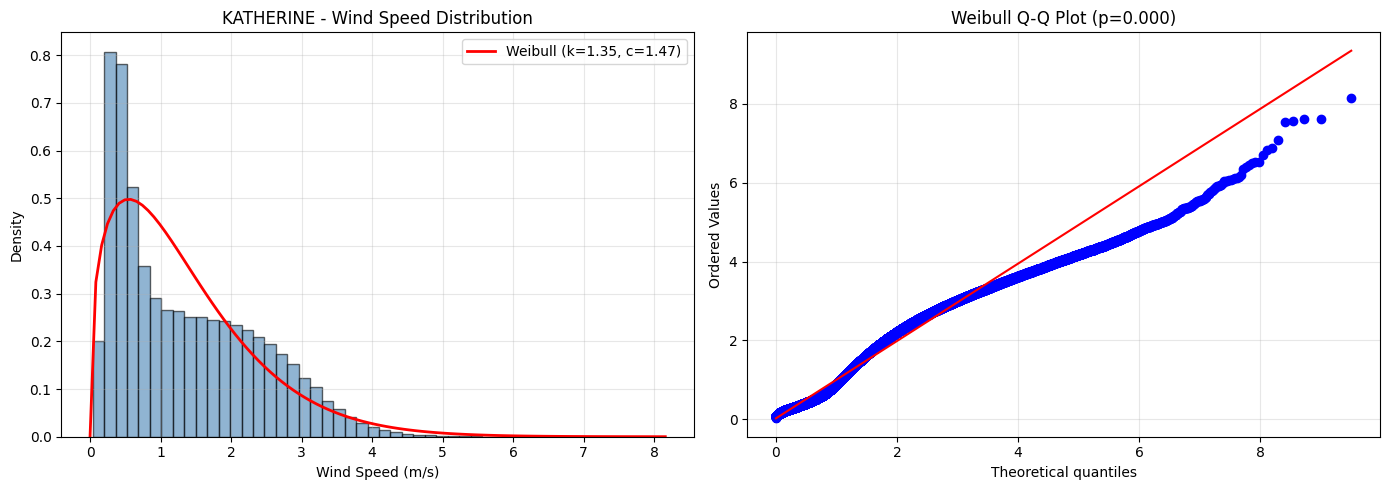


📍 Location: DARWIN
Wind columns found: ['WS_Avg_M51', 'WS_z_M51']
   Valid wind speed samples: 206,559

   📊 Weibull Parameters:
      Shape (k): 1.344
      Scale (c): 1.813 m/s
      Mean: 1.66 m/s
      Std Dev: 1.29 m/s
      Max: 19.04 m/s

   📈 Goodness of Fit:
      KS Statistic: 0.0306
      P-value: 0.0000
      ⚠️  DEVIATES from Weibull distribution


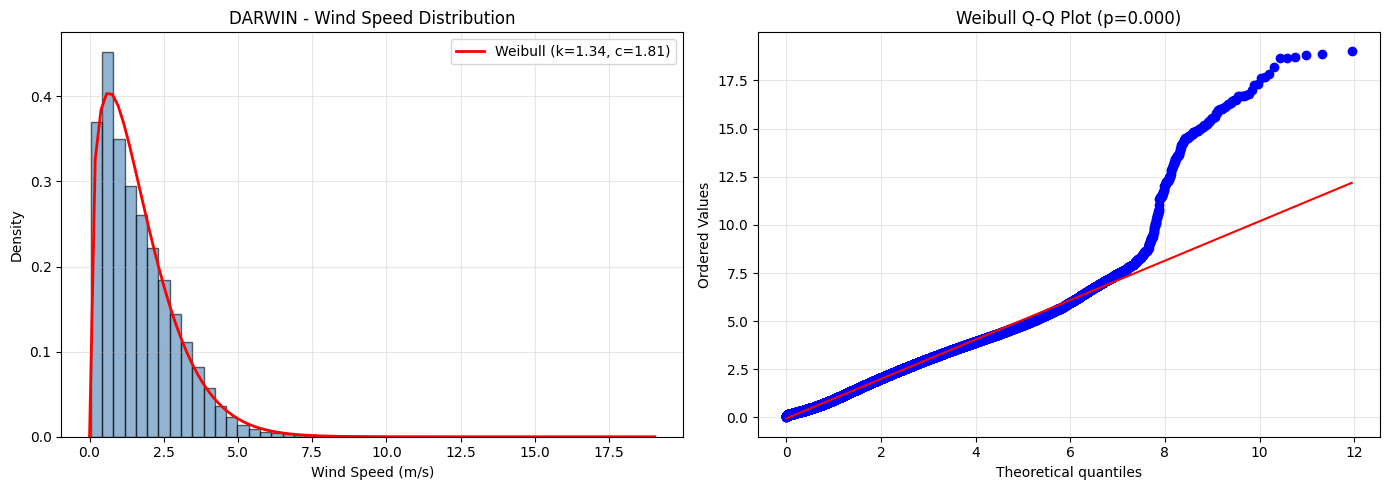


📍 TENNANT_CREEK: No wind speed columns found
   Available columns: []

📍 Location: ALICE_SPRINGS
Wind columns found: ['WS_Avg_M51', 'WS_z_M51']
   Valid wind speed samples: 308,954

   📊 Weibull Parameters:
      Shape (k): 1.292
      Scale (c): 1.443 m/s
      Mean: 1.33 m/s
      Std Dev: 1.03 m/s
      Max: 8.30 m/s

   📈 Goodness of Fit:
      KS Statistic: 0.1134
      P-value: 0.0000
      ⚠️  DEVIATES from Weibull distribution


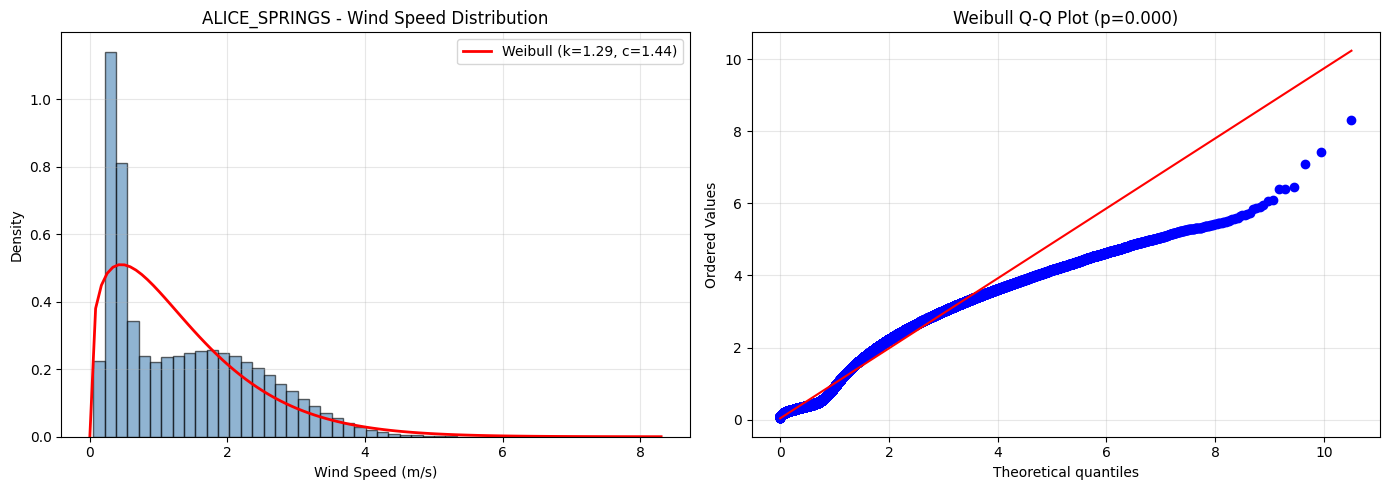


WEIBULL ANALYSIS SUMMARY

      Location  Shape (k)  Scale (m/s)    KS p-value  Mean (m/s)  Std (m/s)
    katherine   1.353914     1.474518  0.000000e+00    1.347999   1.004025
       darwin   1.343888     1.812973 5.775963e-169    1.658230   1.291165
alice_springs   1.292272     1.442966  0.000000e+00    1.330913   1.030229

------------------------------------------------------------
INTERPRETATION:
------------------------------------------------------------

⚠️  katherine: Wind speed DEVIATES from Weibull distribution
   • Shape k = 1.354 (k=2 = Rayleigh distribution)
   • Scale c = 1.47 m/s
   • Mean wind speed = 1.35 m/s

⚠️  darwin: Wind speed DEVIATES from Weibull distribution
   • Shape k = 1.344 (k=2 = Rayleigh distribution)
   • Scale c = 1.81 m/s
   • Mean wind speed = 1.66 m/s

⚠️  alice_springs: Wind speed DEVIATES from Weibull distribution
   • Shape k = 1.292 (k=2 = Rayleigh distribution)
   • Scale c = 1.44 m/s
   • Mean wind speed = 1.33 m/s


In [9]:
# ==========================================================
# WEIBULL DISTRIBUTION ANALYSIS FOR WIND DATA (CORRECTED)
# ==========================================================
from scipy.stats import weibull_min, kstest
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("="*60)
print("WEIBULL DISTRIBUTION ANALYSIS FOR WIND SPEED DATA")
print("="*60)

# Define wind speed column patterns to look for
WIND_SPEED_COLS = ['WS_Avg_M51', 'WS_z_M51', 'WindSpeed', 'wind_speed', 'WS']

weibull_results = []

for loc, df in merged_client_data.items():
    # Find wind speed columns
    wind_cols_found = [col for col in WIND_SPEED_COLS if col in df.columns]
    
    if wind_cols_found:
        print(f"\n{'='*50}")
        print(f"📍 Location: {loc.upper()}")
        print(f"Wind columns found: {wind_cols_found}")
        
        # Use the primary wind speed column (WS_Avg_M51 is the average wind speed)
        wind_col = 'WS_Avg_M51' if 'WS_Avg_M51' in df.columns else wind_cols_found[0]
        
        # Extract wind speed data
        wind_speed = df[wind_col].dropna()
        wind_speed = wind_speed[wind_speed > 0]  # Remove zero/negative values
        
        print(f"   Valid wind speed samples: {len(wind_speed):,}")
        
        if len(wind_speed) > 100:
            # Fit Weibull distribution
            shape, loc_param, scale = weibull_min.fit(wind_speed, floc=0)
            
            # Kolmogorov-Smirnov test
            ks_stat, ks_pvalue = kstest(wind_speed, 'weibull_min', args=(shape, 0, scale))
            
            result = {
                'location': loc,
                'wind_column': wind_col,
                'shape_k': shape,
                'scale_c': scale,
                'ks_statistic': ks_stat,
                'ks_pvalue': ks_pvalue,
                'sample_size': len(wind_speed),
                'mean_wind': wind_speed.mean(),
                'std_wind': wind_speed.std(),
                'max_wind': wind_speed.max()
            }
            weibull_results.append(result)
            
            print(f"\n   📊 Weibull Parameters:")
            print(f"      Shape (k): {shape:.3f}")
            print(f"      Scale (c): {scale:.3f} m/s")
            print(f"      Mean: {wind_speed.mean():.2f} m/s")
            print(f"      Std Dev: {wind_speed.std():.2f} m/s")
            print(f"      Max: {wind_speed.max():.2f} m/s")
            
            print(f"\n   📈 Goodness of Fit:")
            print(f"      KS Statistic: {ks_stat:.4f}")
            print(f"      P-value: {ks_pvalue:.4f}")
            
            if ks_pvalue > 0.05:
                print(f"      ✅ FOLLOWS Weibull distribution")
            else:
                print(f"      ⚠️  DEVIATES from Weibull distribution")
            
            # Plot
            fig, axes = plt.subplots(1, 2, figsize=(14, 5))
            
            x = np.linspace(0, wind_speed.max(), 100)
            pdf_fitted = weibull_min.pdf(x, shape, loc=0, scale=scale)
            
            axes[0].hist(wind_speed, bins=50, density=True, alpha=0.6, color='steelblue', edgecolor='black')
            axes[0].plot(x, pdf_fitted, 'r-', linewidth=2, label=f'Weibull (k={shape:.2f}, c={scale:.2f})')
            axes[0].set_xlabel('Wind Speed (m/s)')
            axes[0].set_ylabel('Density')
            axes[0].set_title(f'{loc.upper()} - Wind Speed Distribution')
            axes[0].legend()
            axes[0].grid(True, alpha=0.3)
            
            from scipy.stats import probplot
            probplot(wind_speed, dist='weibull_min', sparams=(shape, 0, scale), plot=axes[1])
            axes[1].set_title(f'Weibull Q-Q Plot (p={ks_pvalue:.3f})')
            axes[1].grid(True, alpha=0.3)
            
            plt.tight_layout()
            plt.savefig(f'weibull_{loc}.png', dpi=300, bbox_inches='tight')
            plt.show()
            
        else:
            print(f"   ⚠️  Insufficient data: {len(wind_speed)} samples")
    else:
        print(f"\n📍 {loc.upper()}: No wind speed columns found")
        print(f"   Available columns: {[c for c in df.columns if 'WS' in c or 'Wind' in c]}")

# Summary Table
print("\n" + "="*60)
print("WEIBULL ANALYSIS SUMMARY")
print("="*60)

if weibull_results:
    summary_df = pd.DataFrame(weibull_results)
    summary_df = summary_df[['location', 'shape_k', 'scale_c', 'ks_pvalue', 'mean_wind', 'std_wind']]
    summary_df.columns = ['Location', 'Shape (k)', 'Scale (m/s)', 'KS p-value', 'Mean (m/s)', 'Std (m/s)']
    
    print("\n", summary_df.to_string(index=False))
    
    print("\n" + "-"*60)
    print("INTERPRETATION:")
    print("-"*60)
    for _, row in summary_df.iterrows():
        if row['KS p-value'] > 0.05:
            print(f"\n✅ {row['Location']}: Wind speed FOLLOWS Weibull distribution")
        else:
            print(f"\n⚠️  {row['Location']}: Wind speed DEVIATES from Weibull distribution")
        print(f"   • Shape k = {row['Shape (k)']:.3f} (k=2 = Rayleigh distribution)")
        print(f"   • Scale c = {row['Scale (m/s)']:.2f} m/s")
        print(f"   • Mean wind speed = {row['Mean (m/s)']:.2f} m/s")
else:
    print("No wind data found for any location")

# Check Shape

In [10]:
for loc, df in merged_client_data.items():
    print(loc, df.shape)

katherine (432907, 27)
darwin (432908, 24)
tennant_creek (432810, 20)
alice_springs (483029, 27)


# Prepocessing

In [11]:
# ==============================
# PARAMETERS
# ==============================
LOOKBACK = 24

# Define all possible irradiance columns (ONCE)
IRRADIANCE_COLS = [
    'Irradiance_MB0 [W/m-2]',
    'Irradiance_MB1 [W/m-2]'
]

def preprocess_client_data(df, max_missing_pct=50):
    """Preprocess data for a single client."""
    df = df.copy()
    df = df.sort_index()

    # ------------------------------
    # 1. Handle Missing Data
    # ------------------------------
    df = df.dropna(axis=1, how='all')
    missing_pct = (df.isnull().sum() / len(df)) * 100
    df = df.drop(columns=missing_pct[missing_pct > max_missing_pct].index)

    # ------------------------------
    # 2. Drop Non‑Predictive Columns
    # ------------------------------
    drop_keywords = ['Timestamp_Local', 'Timestamp_UNIX', 'Hour_UTC', 'Hour_Local']
    df = df.drop(columns=[c for c in df.columns if any(k in c for k in drop_keywords)],
                 errors='ignore')

    # ------------------------------
    # 3. Identify Available Irradiance Targets for this client
    # ------------------------------
    available_targets = [col for col in IRRADIANCE_COLS if col in df.columns]
    print(f"  Available irradiance targets: {available_targets}")

    # ------------------------------
    # 4.5 Irradiance Interaction Features
    # ------------------------------
    if all(col in df.columns for col in IRRADIANCE_COLS):
        
        df['irradiance_diff'] = (
            df['Irradiance_MB0 [W/m-2]'] - df['Irradiance_MB1 [W/m-2]']
        )
    
        df['irradiance_ratio'] = (
            df['Irradiance_MB0 [W/m-2]'] /
            (df['Irradiance_MB1 [W/m-2]'] + 1e-6)
        )
    
        # Optional but VERY helpful (recommended)
        df['irradiance_sum'] = (
            df['Irradiance_MB0 [W/m-2]'] + df['Irradiance_MB1 [W/m-2]']
        )
    
    # ------------------------------
    # 4. Outlier Handling for ALL irradiance sensors
    # ------------------------------
    for target in available_targets:
        df[target] = df[target].clip(0, 1500)  # physical irradiance max

    if 'AirTemperatureC_M90' in df:
        df['AirTemperatureC_M90'] = df['AirTemperatureC_M90'].clip(-10, 60)

    # ------------------------------
    # 5. Interpolation & Imputation
    # ------------------------------
    numeric_cols = df.select_dtypes(include=np.number).columns
    df[numeric_cols] = (
        df[numeric_cols]
        .interpolate(method='linear', limit_direction='both')
        .ffill()
        .bfill()
    )
    df = df.fillna(df.mean())

    # ------------------------------
    # 6. Time Features
    # ------------------------------
    df['hour'] = df.index.hour
    df['dayofweek'] = df.index.dayofweek
    df['dayofyear'] = df.index.dayofyear
    df['month'] = df.index.month
    df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)

    # Cyclical encoding
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    df['dow_sin'] = np.sin(2 * np.pi * df['dayofweek'] / 7)
    df['dow_cos'] = np.cos(2 * np.pi * df['dayofweek'] / 7)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

    for col in available_targets:
        if col in df.columns:
            tail_values = df[col].tail(5000)

            # if the tail is constant
            if tail_values.nunique() == 1:
                change_points = df[col].diff().abs() > 1e-6
                if change_points.any():
                    last_change = change_points[::-1].idxmax()
                    df = df.loc[:last_change]

    # causal lag
    for col in available_targets:
        if col in df.columns:
            df[f'{col}_lag1'] = df[col].shift(1).fillna(0)

    return df, available_targets


# ==============================
# SEQUENCE CREATION FUNCTION
# ==============================
def create_sequences(X, y, lookback):
    """
    Create sequences for multi-target prediction.
    y shape will be (samples, n_targets) where n_targets varies by client.
    """
    X_seq, y_seq = [], []

    for i in range(len(X) - lookback):
        X_seq.append(X[i:i + lookback])
        y_seq.append(y[i + lookback])  # shape: (n_targets,)

    return np.array(X_seq), np.array(y_seq)


# ==============================
# MAIN PREPROCESSING PIPELINE
# ==============================
print("="*60)
print("STARTING DATA PREPROCESSING")
print("="*60)

client_targets = {}
preprocessed_data = {}

for loc, df in merged_client_data.items():
    print(f"\n📍 Preprocessing {loc}...")
    df, available_targets = preprocess_client_data(df)
    preprocessed_data[loc] = df
    client_targets[loc] = available_targets
    
    print(f"   Final columns: {len(df.columns)}")
    print(f"   Predicting: {available_targets}")

def find_common_features(data_dict):
    common = None
    for df in data_dict.values():
        features = set(df.columns)
        common = features if common is None else common.intersection(features)
    return sorted(list(common))

common_features = find_common_features(merged_client_data)

common_features = find_common_features(preprocessed_data)

print(f"\n✅ Common features across all clients: {len(common_features)}")

for loc in preprocessed_data:
    preprocessed_data[loc] = preprocessed_data[loc][common_features].copy()



STARTING DATA PREPROCESSING

📍 Preprocessing katherine...
  Available irradiance targets: ['Irradiance_MB0 [W/m-2]', 'Irradiance_MB1 [W/m-2]']
   Final columns: 28
   Predicting: ['Irradiance_MB0 [W/m-2]', 'Irradiance_MB1 [W/m-2]']

📍 Preprocessing darwin...
  Available irradiance targets: ['Irradiance_MB0 [W/m-2]', 'Irradiance_MB1 [W/m-2]']
   Final columns: 25
   Predicting: ['Irradiance_MB0 [W/m-2]', 'Irradiance_MB1 [W/m-2]']

📍 Preprocessing tennant_creek...
  Available irradiance targets: ['Irradiance_MB0 [W/m-2]', 'Irradiance_MB1 [W/m-2]']
   Final columns: 28
   Predicting: ['Irradiance_MB0 [W/m-2]', 'Irradiance_MB1 [W/m-2]']

📍 Preprocessing alice_springs...
  Available irradiance targets: ['Irradiance_MB0 [W/m-2]', 'Irradiance_MB1 [W/m-2]']
   Final columns: 31
   Predicting: ['Irradiance_MB0 [W/m-2]', 'Irradiance_MB1 [W/m-2]']

✅ Common features across all clients: 25


In [12]:
for loc, df in preprocessed_data.items():
    print(loc, df.shape)

katherine (303106, 25)
darwin (384966, 25)
tennant_creek (432810, 25)
alice_springs (483029, 25)


In [13]:
for loc, df in merged_client_data.items():
    print(loc, df.shape)

katherine (432907, 27)
darwin (432908, 24)
tennant_creek (432810, 20)
alice_springs (483029, 27)


In [14]:
for loc in merged_client_data:

    original_rows = merged_client_data[loc].shape[0]
    processed_rows = preprocessed_data[loc].shape[0]

    omitted_rows = original_rows - processed_rows

    omitted_ratio = (omitted_rows / original_rows) * 100
    remaining_ratio = (processed_rows / original_rows) * 100

    print(f"\nLocation: {loc}")
    print(f"Original rows     : {original_rows}")
    print(f"Processed rows    : {processed_rows}")
    print(f"Omitted rows      : {omitted_rows}")
    print(f"Omitted %         : {omitted_ratio:.2f}%")
    print(f"Remaining %       : {remaining_ratio:.2f}%")


Location: katherine
Original rows     : 432907
Processed rows    : 303106
Omitted rows      : 129801
Omitted %         : 29.98%
Remaining %       : 70.02%

Location: darwin
Original rows     : 432908
Processed rows    : 384966
Omitted rows      : 47942
Omitted %         : 11.07%
Remaining %       : 88.93%

Location: tennant_creek
Original rows     : 432810
Processed rows    : 432810
Omitted rows      : 0
Omitted %         : 0.00%
Remaining %       : 100.00%

Location: alice_springs
Original rows     : 483029
Processed rows    : 483029
Omitted rows      : 0
Omitted %         : 0.00%
Remaining %       : 100.00%


In [15]:
# Display columns as Python lists
for loc, df in preprocessed_data.items():
    print(f"\n{loc.upper()} columns:")
    print(df.columns.tolist())


KATHERINE columns:
['AirTemperatureC_M90', 'Irradiance_MB0 [W/m-2]', 'Irradiance_MB0 [W/m-2]_lag1', 'Irradiance_MB1 [W/m-2]', 'Irradiance_MB1 [W/m-2]_lag1', 'RainAccumMM_M90', 'RelativeHumidity_M90', 'UnitTemp_MB0 [deg C]', 'UnitTemp_MB1 [deg C]', 'Voltage_MB0 [V]', 'Voltage_MB1 [V]', 'dayofweek', 'dayofyear', 'dow_cos', 'dow_sin', 'hour', 'hour_cos', 'hour_sin', 'irradiance_diff', 'irradiance_ratio', 'irradiance_sum', 'is_weekend', 'month', 'month_cos', 'month_sin']

DARWIN columns:
['AirTemperatureC_M90', 'Irradiance_MB0 [W/m-2]', 'Irradiance_MB0 [W/m-2]_lag1', 'Irradiance_MB1 [W/m-2]', 'Irradiance_MB1 [W/m-2]_lag1', 'RainAccumMM_M90', 'RelativeHumidity_M90', 'UnitTemp_MB0 [deg C]', 'UnitTemp_MB1 [deg C]', 'Voltage_MB0 [V]', 'Voltage_MB1 [V]', 'dayofweek', 'dayofyear', 'dow_cos', 'dow_sin', 'hour', 'hour_cos', 'hour_sin', 'irradiance_diff', 'irradiance_ratio', 'irradiance_sum', 'is_weekend', 'month', 'month_cos', 'month_sin']

TENNANT_CREEK columns:
['AirTemperatureC_M90', 'Irradian

# Show Day-Night Pattern

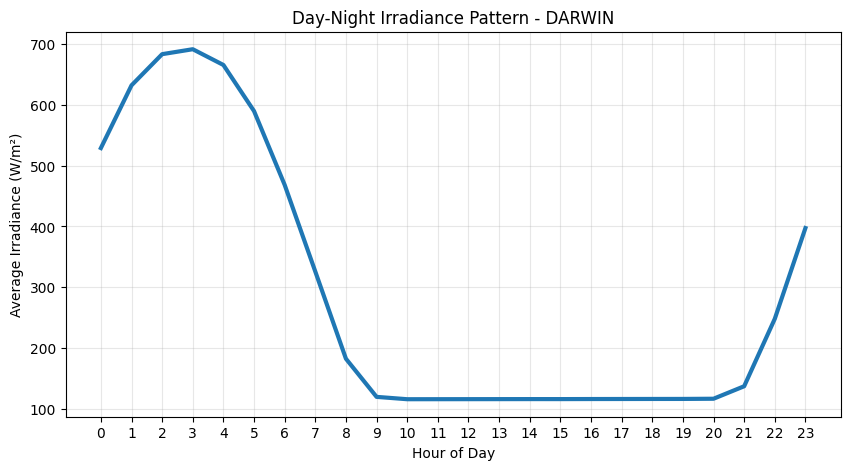

In [16]:
import matplotlib.pyplot as plt
import pandas as pd

# Example location
loc = 'darwin'

df = preprocessed_data[loc].copy()

# Average irradiance by hour
hourly_pattern = df.groupby('hour')['Irradiance_MB0 [W/m-2]'].mean()

plt.figure(figsize=(10,5))
plt.plot(hourly_pattern.index, hourly_pattern.values, linewidth=3)

plt.title(f'Day-Night Irradiance Pattern - {loc.upper()}')
plt.xlabel('Hour of Day')
plt.ylabel('Average Irradiance (W/m²)')
plt.grid(True, alpha=0.3)

plt.xticks(range(0,24))
plt.savefig(f'Day-Night Irradiance Pattern - {loc.upper()}.png')
plt.show()

# Sesonal Pattern

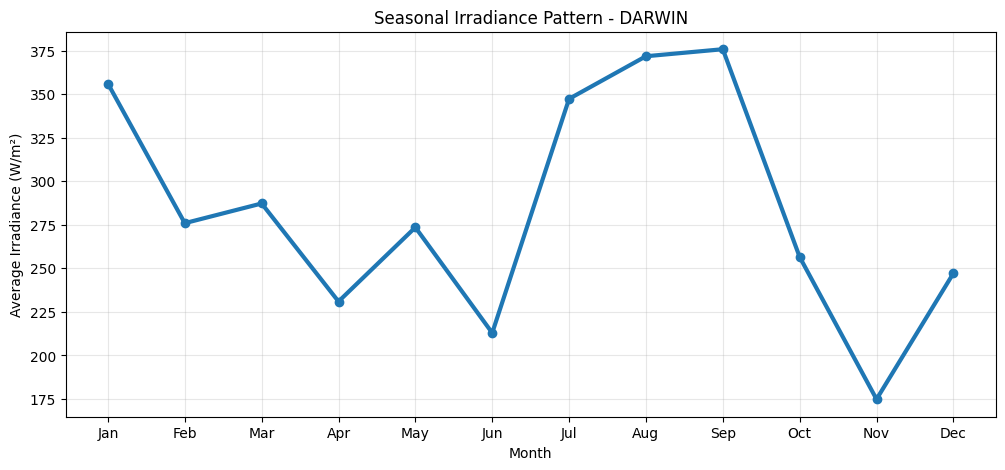

In [17]:
import matplotlib.pyplot as plt

loc = 'darwin'

df = preprocessed_data[loc].copy()

monthly_pattern = df.groupby('month')['Irradiance_MB0 [W/m-2]'].mean()

month_names = [
    'Jan','Feb','Mar','Apr','May','Jun',
    'Jul','Aug','Sep','Oct','Nov','Dec'
]

plt.figure(figsize=(12,5))
plt.plot(monthly_pattern.index, monthly_pattern.values,
         marker='o', linewidth=3)

plt.xticks(range(1,13), month_names)

plt.title(f'Seasonal Irradiance Pattern - {loc.upper()}')
plt.xlabel('Month')
plt.ylabel('Average Irradiance (W/m²)')
plt.grid(True, alpha=0.3)
plt.savefig(f'Seasonal Irradiance Pattern - {loc.upper()}.png')
plt.show()

# HeatMap

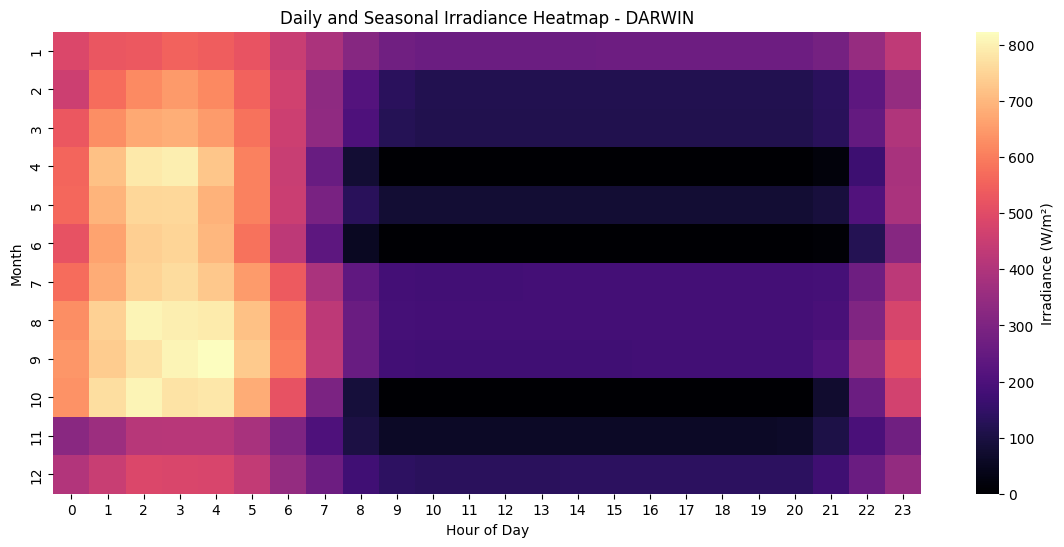

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

loc = 'darwin'

df = preprocessed_data[loc].copy()

pivot_table = df.pivot_table(
    values='Irradiance_MB0 [W/m-2]',
    index='month',
    columns='hour',
    aggfunc='mean'
)

plt.figure(figsize=(14,6))

sns.heatmap(
    pivot_table,
    cmap='magma',   # FIXED
    cbar_kws={'label': 'Irradiance (W/m²)'}
)

plt.title(f'Daily and Seasonal Irradiance Heatmap - {loc.upper()}')
plt.xlabel('Hour of Day')
plt.ylabel('Month')
plt.savefig(f'Daily and Seasonal Irradiance Heatmap - {loc.upper()}.png')
plt.show()

# Train, Validation, Split

In [19]:
final_clients_data = {}
for loc, df in preprocessed_data.items():
    print(f"\nProcessing {loc}...")

    available_targets = client_targets[loc]  # from preprocessing step
    n = len(df)
    train_end = int(0.7 * n)
    val_end = int(0.85 * n)

    train_df = df.iloc[:train_end]
    val_df = df.iloc[train_end:val_end]
    test_df = df.iloc[val_end:]

    feature_cols = train_df.columns.drop(available_targets)

    X_train = train_df[feature_cols]
    y_train = train_df[available_targets]

    X_val = val_df[feature_cols]
    y_val = val_df[available_targets]

    X_test = test_df[feature_cols]
    y_test = test_df[available_targets]

    # scaling
    feature_scaler = MinMaxScaler()
    target_scaler = MinMaxScaler()

    X_train_scaled = feature_scaler.fit_transform(X_train)
    X_val_scaled = feature_scaler.transform(X_val)
    X_test_scaled = feature_scaler.transform(X_test)

    y_train_scaled = target_scaler.fit_transform(y_train)
    y_val_scaled = target_scaler.transform(y_val)
    y_test_scaled = target_scaler.transform(y_test)

    # sequences
    X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, LOOKBACK)
    X_val_seq, y_val_seq = create_sequences(X_val_scaled, y_val_scaled, LOOKBACK)
    X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_scaled, LOOKBACK)

    final_clients_data[loc] = {
        "X_train": X_train_seq,
        "y_train": y_train_seq,
        "X_val": X_val_seq,
        "y_val": y_val_seq,
        "X_test": X_test_seq,
        "y_test": y_test_seq,
        "feature_scaler": feature_scaler,
        "target_scaler": target_scaler
    }

    print(f"{loc}: Train {X_train_seq.shape}, Val {X_val_seq.shape}, Test {X_test_seq.shape}")


Processing katherine...
katherine: Train (212150, 24, 23), Val (45442, 24, 23), Test (45442, 24, 23)

Processing darwin...
darwin: Train (269452, 24, 23), Val (57721, 24, 23), Test (57721, 24, 23)

Processing tennant_creek...
tennant_creek: Train (302943, 24, 23), Val (64897, 24, 23), Test (64898, 24, 23)

Processing alice_springs...
alice_springs: Train (338096, 24, 23), Val (72430, 24, 23), Test (72431, 24, 23)


In [20]:
print(f"\n{loc} Feature Columns ({len(feature_cols)}):")
for col in feature_cols:
    print(col)

print(f"\n{loc} Target Columns ({len(available_targets)}):")
for col in available_targets:
    print(col)


alice_springs Feature Columns (23):
AirTemperatureC_M90
Irradiance_MB0 [W/m-2]_lag1
Irradiance_MB1 [W/m-2]_lag1
RainAccumMM_M90
RelativeHumidity_M90
UnitTemp_MB0 [deg C]
UnitTemp_MB1 [deg C]
Voltage_MB0 [V]
Voltage_MB1 [V]
dayofweek
dayofyear
dow_cos
dow_sin
hour
hour_cos
hour_sin
irradiance_diff
irradiance_ratio
irradiance_sum
is_weekend
month
month_cos
month_sin

alice_springs Target Columns (2):
Irradiance_MB0 [W/m-2]
Irradiance_MB1 [W/m-2]


# Convert into Torch

In [21]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

pytorch_client_data = {}
scaler_store = {}

batch_size = 128

def numpy_to_torch(arr, dtype=torch.float32):
  return torch.as_tensor(arr, dtype=dtype)

for loc, data in final_clients_data.items():
    X_train_t = numpy_to_torch(data["X_train"])
    y_train_t = numpy_to_torch(data["y_train"])

    X_val_t   = numpy_to_torch(data["X_val"])
    y_val_t   = numpy_to_torch(data["y_val"])

    X_test_t  = numpy_to_torch(data["X_test"])
    y_test_t  = numpy_to_torch(data["y_test"])

    train_dataset = TensorDataset(X_train_t, y_train_t)
    val_dataset   = TensorDataset(X_val_t,   y_val_t)
    test_dataset  = TensorDataset(X_test_t,  y_test_t)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True           

    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False

    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False

    )

    pytorch_client_data[loc] = {
        "train_dataloader": train_loader,
        "val_dataloader":   val_loader,
        "test_dataloader":  test_loader,
    }


    scaler_store[loc] = {
        "feature_scaler": data["feature_scaler"],
        "target_scaler":  data["target_scaler"],
    }

    print(
        f"{loc}: "
        f"{train_dataset.tensors[0].shape[0]} train, "
        f"{val_dataset.tensors[0].shape[0]}   val, "
        f"{test_dataset.tensors[0].shape[0]}   test"
    )


print("\n🗂️  PyTorch client data structure ready.")
print(f"Total clients loaded: {len(pytorch_client_data)}")


Using device: cuda
katherine: 212150 train, 45442   val, 45442   test
darwin: 269452 train, 57721   val, 57721   test
tennant_creek: 302943 train, 64897   val, 64898   test
alice_springs: 338096 train, 72430   val, 72431   test

🗂️  PyTorch client data structure ready.
Total clients loaded: 4


# Drift Initialization

In [22]:
import numpy as np
from collections import deque
import math

class ADWINDriftDetector:
    """
    ADWIN (ADaptive WINdowing) Drift Detector
    Original paper: Bifet & Gavalda (2007)
    """
    
    def __init__(self, delta=0.002, max_window_size=1000, min_window_size=100, cooldown_rounds=2):
        """
        Args:
            delta: Confidence level (lower = more sensitive)
            max_window_size: Maximum window size
            min_window_size: Minimum window size before detecting drift
            cooldown_rounds: Rounds to wait after drift
        """
        self.delta = delta
        self.max_window_size = max_window_size
        self.min_window_size = min_window_size
        self.cooldown_rounds = cooldown_rounds
        
        # Main window storing values
        self.window = deque(maxlen=max_window_size)
        self.total = 0.0
        self.total_squares = 0.0
        self.n = 0
        
        # State variables
        self.last_drift_round = -cooldown_rounds
        self.current_round = 0
        self.drift_detected = False
        
        # For efficiency - precompute prefix sums
        self.prefix_sum = []
        self.prefix_sum_squares = []
        
    def _update_prefix_sums(self):
        """Update prefix sums for efficient sub-window calculations"""
        self.prefix_sum = [0.0]
        self.prefix_sum_squares = [0.0]
        
        for i, val in enumerate(self.window):
            self.prefix_sum.append(self.prefix_sum[-1] + val)
            self.prefix_sum_squares.append(self.prefix_sum_squares[-1] + (val * val))
    
    def _mean(self, start, end):
        """Calculate mean of window[start:end] using prefix sums"""
        if start >= end:
            return 0.0
        count = end - start
        total = self.prefix_sum[end] - self.prefix_sum[start]
        return total / count if count > 0 else 0.0
    
    def _variance(self, start, end):
        """Calculate variance of window[start:end]"""
        if end - start < 2:
            return 0.0
        count = end - start
        mean = self._mean(start, end)
        total_squares = self.prefix_sum_squares[end] - self.prefix_sum_squares[start]
        variance = (total_squares / count) - (mean * mean)
        return max(0.0, variance)
    
    def _cut_points(self):
        """Find best cut point and check for drift"""
        n = len(self.window)
        if n < self.min_window_size:
            return None, None, 0.0
        
        # Update prefix sums
        self._update_prefix_sums()
        
        best_cut = None
        best_epsilon = 0.0
        max_n0 = 0
        max_n1 = 0
        
        # Try different cut points
        for cut in range(self.min_window_size, n - self.min_window_size + 1):
            n0 = cut
            n1 = n - cut
            
            # Calculate means
            mu0 = self._mean(0, cut)
            mu1 = self._mean(cut, n)
            
            # Calculate variances
            var0 = self._variance(0, cut)
            var1 = self._variance(cut, n)
            
            # Calculate pooled variance
            pooled_var = ((n0 * var0) + (n1 * var1)) / (n0 + n1)
            if pooled_var < 1e-8:
                pooled_var = 1e-8
            
            # Calculate epsilon threshold
            epsilon = math.sqrt(1.0 / (2.0 * min(n0, n1)) * 
                               math.log(2.0 / self.delta))
            
            # Check if means differ significantly
            if abs(mu0 - mu1) > epsilon:
                # Calculate drift magnitude
                drift_magnitude = abs(mu0 - mu1) / (math.sqrt(pooled_var) + 1e-8)
                
                if drift_magnitude > best_epsilon:
                    best_epsilon = drift_magnitude
                    best_cut = cut
                    max_n0 = n0
                    max_n1 = n1
        
        return best_cut, best_epsilon, max_n0 + max_n1
    
    def add_value(self, value):
        """Add a single value to the window"""
        self.window.append(value)
        self.n += 1
        self.total += value
        self.total_squares += value * value
    
    def add_batch_predictions(self, y_true_batch, y_pred_batch, threshold=0.1):
        """
        Add batch predictions and detect drift
        Returns: (drift_detected, drift_score)
        """
        # Convert to numpy if tensors
        if hasattr(y_true_batch, 'cpu'):
            y_true_batch = y_true_batch.cpu().numpy()
        if hasattr(y_pred_batch, 'cpu'):
            y_pred_batch = y_pred_batch.cpu().numpy()
        
        # Calculate errors (absolute error normalized)
        if len(y_true_batch.shape) > 1 and y_true_batch.shape[1] > 1:
            # Multi-target: average absolute error across targets
            errors = np.mean(np.abs(y_true_batch - y_pred_batch), axis=1)
        else:
            errors = np.abs(y_true_batch.flatten() - y_pred_batch.flatten())
        
        # Add each error to window
        for error in errors:
            self.add_value(error)
        
        # Check for drift
        return self.detect_drift()
    
    def detect_drift(self):
        """Check if drift has occurred"""
        cut_point, epsilon, total_n = self._cut_points()
        
        drift_score = epsilon if epsilon > 0 else 0.0
        drift_detected = False
        details = {'cut_point': cut_point, 'epsilon': epsilon, 'total_n': total_n}
        
        if cut_point is not None and total_n >= self.min_window_size:
            drift_detected = True
            new_window = list(self.window)[cut_point:]
            self.window = deque(new_window, maxlen=self.max_window_size)
            self.total = sum(self.window)
            self.total_squares = sum(x * x for x in self.window)
            self.n = len(self.window)
            details['window_cut'] = True
            details['new_window_size'] = self.n
        
        return drift_detected, drift_score, details
    
    def detect_batch(self, y_true_batch, y_pred_batch):
        """Main detection method for batch processing"""
        self.current_round += 1
        
        rounds_since_drift = self.current_round - self.last_drift_round
        in_cooldown = rounds_since_drift <= self.cooldown_rounds
        
        if in_cooldown:
            return 0.0, False, {'cooldown': True}
        
        drift_detected, drift_score, details = self.add_batch_predictions(y_true_batch, y_pred_batch)
        
        if drift_detected:
            self.last_drift_round = self.current_round
            self.drift_detected = True
            return drift_score, True, details
        
        self.drift_detected = False
        return drift_score, False, details
    
    def get_window_stats(self):
        """Get current window statistics"""
        if len(self.window) == 0:
            return {'size': 0, 'mean': 0.0, 'std': 0.0}
        
        mean = self.total / self.n if self.n > 0 else 0.0
        variance = (self.total_squares / self.n) - (mean * mean)
        std = math.sqrt(max(0.0, variance))
        
        return {
            'size': len(self.window),
            'mean': mean,
            'std': std,
            'total': self.total
        }
    
    def reset(self):
        """Reset the detector"""
        self.window.clear()
        self.total = 0.0
        self.total_squares = 0.0
        self.n = 0
        self.drift_detected = False
        self.prefix_sum = []
        self.prefix_sum_squares = []


class FederatedDriftMonitorADWIN:
    """Federated version of ADWIN"""
    
    def __init__(self, delta=0.002, max_window_size=1000, min_window_size=100):
        self.delta = delta
        self.max_window_size = max_window_size
        self.min_window_size = min_window_size
        self.detectors = {}

    def fit_client(self, client_id, reference_data=None):
        """Initialize ADWIN detector for a client"""
        detector = ADWINDriftDetector(
            delta=self.delta,
            max_window_size=self.max_window_size,
            min_window_size=self.min_window_size
        )
        self.detectors[client_id] = detector
        return detector

    def detect_client(self, client_id, y_true_batch, y_pred_batch):

        detector = self.detectors.get(client_id)
        if detector is None:
            return 0.0, False
        
        return detector.detect_batch(y_true_batch, y_pred_batch)
    # score, drift, details = federated_monitor.detect_client(
    #             loc, all_true, all_preds
    #         )
            
    def get_detector_stats(self, client_id):
        """Get current window statistics for a client"""
        detector = self.detectors.get(client_id)
        if detector:
            return detector.get_window_stats()
        return None

# Drift Monitor

In [23]:
federated_monitor = FederatedDriftMonitorADWIN(
    delta=0.002,           # Confidence (lower = more sensitive)
    max_window_size=1000,  # Maximum window size
    min_window_size=100    # Minimum samples before detecting
)

# Initialize detectors for each client
for loc in pytorch_client_data.keys():
    federated_monitor.fit_client(loc)

print("✅ ADWIN Drift monitor initialized")

✅ ADWIN Drift monitor initialized


# Model Architrcture

In [24]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# ==============================
# Squeeze-and-Excitation Block
# ==============================
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction),
            nn.ReLU(),
            nn.Linear(channels // reduction, channels),
            nn.Sigmoid()
        )

    def forward(self, x):
        # x: [B, C, T]
        b, c, _ = x.size()
        y = x.mean(dim=2)
        y = self.fc(y).view(b, c, 1)
        return x * y


# ==============================
# Residual Block
# ==============================
class ResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.2):
        super().__init__()

        self.conv1 = nn.Conv1d(in_ch, out_ch, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(out_ch)

        self.conv2 = nn.Conv1d(out_ch, out_ch, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm1d(out_ch)

        self.se = SEBlock(out_ch)
        self.dropout = nn.Dropout(dropout)

        # Match dimensions for residual
        self.shortcut = nn.Conv1d(in_ch, out_ch, kernel_size=1) if in_ch != out_ch else nn.Identity()

    def forward(self, x):
        identity = self.shortcut(x)

        out = F.relu(self.bn1(self.conv1(x)))
        out = self.dropout(out)

        out = self.bn2(self.conv2(out))
        out = self.se(out)

        out += identity
        return F.relu(out)


# ==============================
# Strong CNN Model
# ==============================
class StrongCNN(nn.Module):
    def __init__(self, input_size, dropout=0.2):
        super().__init__()

        self.stem = nn.Sequential(
            nn.Conv1d(input_size, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU()
        )

        # Deeper residual stack
        self.layer1 = ResidualBlock(64, 128, dropout)
        self.layer2 = ResidualBlock(128, 256, dropout)
        self.layer3 = ResidualBlock(256, 256, dropout)

        # Multi-scale feature extraction
        self.multi_scale = nn.ModuleList([
            nn.Conv1d(256, 256, kernel_size=3, padding=1),
            nn.Conv1d(256, 256, kernel_size=5, padding=2),
            nn.Conv1d(256, 256, kernel_size=7, padding=3),
        ])

        self.bn = nn.BatchNorm1d(256)

        self.pool = nn.AdaptiveAvgPool1d(1)

        self.fc = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(64, 2)
        )

    def forward(self, x):
        # x: [B, T, F]
        x = x.transpose(1, 2)  # → [B, F, T]

        x = self.stem(x)

        x = self.layer1(x)
        x = self.layer2(x)
        # x = self.layer3(x)

        # Multi-scale aggregation
        ms_out = sum(conv(x) for conv in self.multi_scale) / len(self.multi_scale)
        x = F.relu(self.bn(ms_out))

        x = self.pool(x).squeeze(-1)  # [B, 256]

        return self.fc(x)

In [25]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

first_loc = list(final_clients_data.keys())[0]
input_size = final_clients_data[first_loc]["X_train"].shape[2]
output_size = final_clients_data[first_loc]["y_train"].shape[1]

print(f"Input feature size: {input_size}")
print(f"Output target size: {output_size}")
GLOBAL_OUTPUT_SIZE = len(IRRADIANCE_COLS)

global_model = StrongCNN(
    input_size=23).to(device)

Using device: cuda
Input feature size: 23
Output target size: 2


# Loss Funtion

In [26]:
mse = nn.MSELoss()
def loss_fn(pred, target):
    loss = (
    0.5 * mse(pred[:, 0], target[:, 0]) +
    0.5 * mse(pred[:, 1], target[:, 1]))

    return loss

# Retrain & Drif Weight Calculation Function

In [27]:
def drift_weight_enhanced(score, drift_flag, base_weight, alpha=0.4, beta=0.0):
    if beta > 0.0:
        adj = 1.0 / (1.0 + beta * score * 10)
    else:
        adj = 1.0 - alpha if drift_flag else 1.0
    return base_weight * adj

# Hyper Perameters

In [28]:
# Hyper‑parameters
num_communication_rounds = 20
local_epochs = 4
learning_rate = 0.00005
l2_lambda = 0.0001

history = {
    "global_train_loss": [],
    "global_val_loss": [],
    "client_train_losses": {loc: [] for loc in final_clients_data},
    "client_val_losses":   {loc: [] for loc in final_clients_data},
}

print(f"Clients: {len(final_clients_data)}")
print(f"Rounds: {num_communication_rounds}")
print(f"\nStarting federated training with {len(pytorch_client_data)} clients...")
print(f"Total communication rounds: {num_communication_rounds}")
print(f"Local epochs per client: {local_epochs}")
print(f"Learning rate: {learning_rate}")
print(f"L2 regularization: {l2_lambda}")

Clients: 4
Rounds: 20

Starting federated training with 4 clients...
Total communication rounds: 20
Local epochs per client: 4
Learning rate: 5e-05
L2 regularization: 0.0001


# Train and Validation Function

In [29]:
# ==============================
# 2. Enhanced Client Training with Regularization
# ==============================
def client_train_fn_regularized(model, train_loader, val_loader, optimizer, loss_fn, 
                                 local_epochs, device, patience=2, l2_lambda=0.001):
    """
    Train client model locally with early stopping and L2 regularization.
    """
    model.train()
    best_val_loss = float('inf')
    patience_counter = 0
    best_model_state = None
    
    for epoch in range(local_epochs):
        # Training phase
        model.train()
        epoch_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            
            optimizer.zero_grad()
            output = model(X_batch)
            
            # Standard loss
            loss = loss_fn(output, y_batch)
            
            # Add L2 regularization
            l2_reg = 0
            for param in model.parameters():
                l2_reg += torch.norm(param, 2)
            loss += l2_lambda * l2_reg
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            epoch_loss += loss.item()
        
        # Validation phase after each epoch
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                output = model(X_batch)
                val_loss += loss_fn(output, y_batch).item()
        val_loss /= len(val_loader)
        
        # Early stopping check
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"    Early stopping at epoch {epoch + 1}")
                break
    
    # Return best model state
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
    
    avg_loss = epoch_loss / len(train_loader)
    return model.state_dict(), avg_loss, best_val_loss


# Training Loop


--- Communication Round 1/20 ---

📚 LOCAL TRAINING PHASE
----------------------------------------

  Training katherine...
    Early stopping at epoch 4
    ✓ katherine: Train 0.014880 | Val 0.002553

  Training darwin...
    ✓ darwin: Train 0.013394 | Val 0.002581

  Training tennant_creek...
    ✓ tennant_creek: Train 0.012475 | Val 0.002296

  Training alice_springs...
    Early stopping at epoch 4
    ✓ alice_springs: Train 0.011376 | Val 0.002011

🔍 ENHANCED DRIFT DETECTION PHASE
----------------------------------------

  🚨 DRIFT detected for KATHERINE!
      Combined score: 0.6801
      Mean shift: 0.0000
      Variance shift: 0.0000
      Distribution shift: 0.0000
      Concept drift: 0.0000
      Drift votes: 0/4
      Prediction error: 0.1576


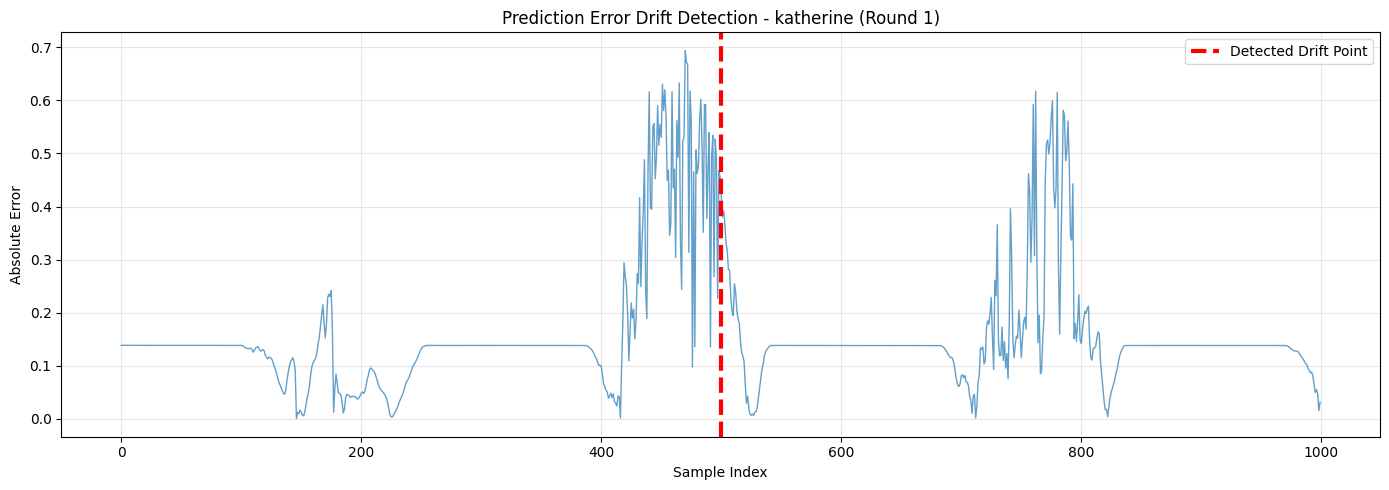


  🚨 DRIFT detected for DARWIN!
      Combined score: 0.7740
      Mean shift: 0.0000
      Variance shift: 0.0000
      Distribution shift: 0.0000
      Concept drift: 0.0000
      Drift votes: 0/4
      Prediction error: 0.1921


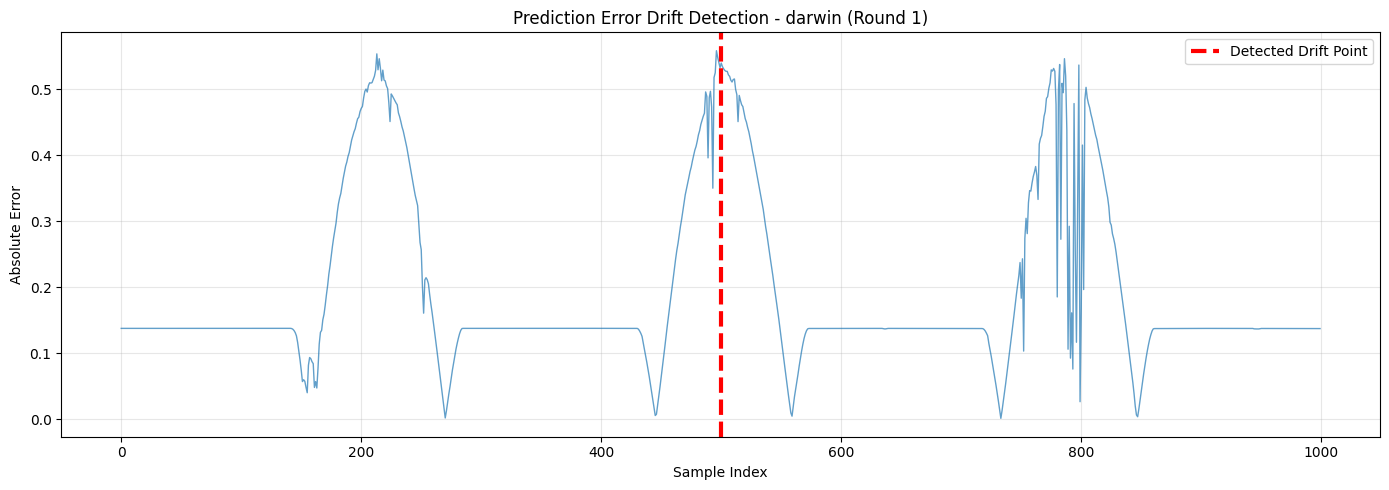


  🚨 DRIFT detected for TENNANT_CREEK!
      Combined score: 1.1194
      Mean shift: 0.0000
      Variance shift: 0.0000
      Distribution shift: 0.0000
      Concept drift: 0.0000
      Drift votes: 0/4
      Prediction error: 0.2505


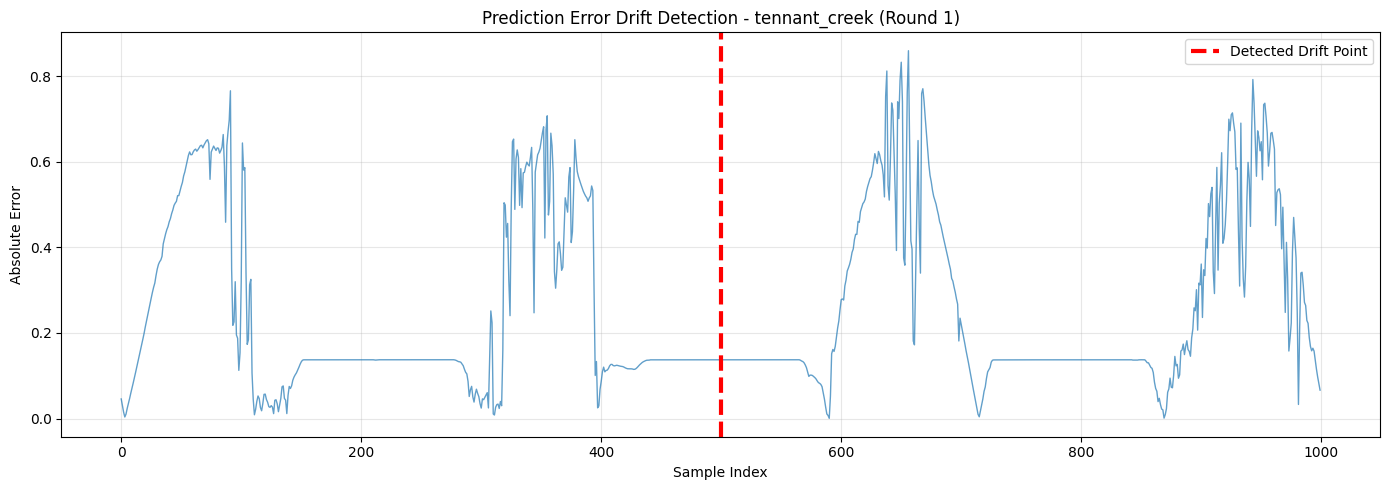


  🚨 DRIFT detected for ALICE_SPRINGS!
      Combined score: 1.2528
      Mean shift: 0.0000
      Variance shift: 0.0000
      Distribution shift: 0.0000
      Concept drift: 0.0000
      Drift votes: 0/4
      Prediction error: 0.2601


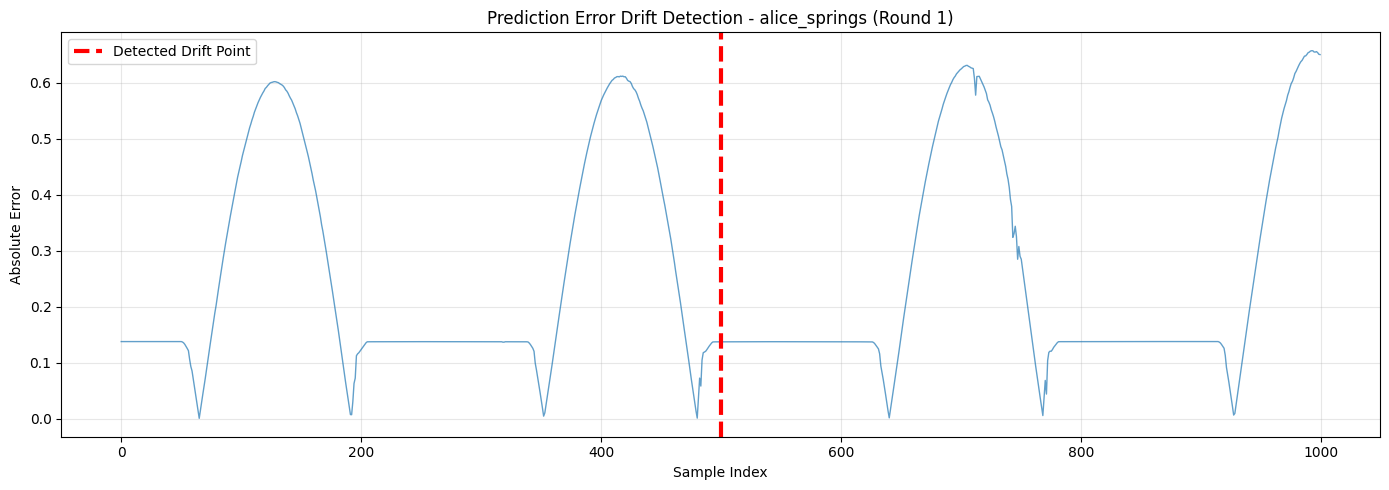


🔄 ADAPTIVE RESPONSE FOR DRIFTED CLIENTS
----------------------------------------

  📈 MILD DRIFT for katherine
    Extra epochs: 1, Dropout: 0.3, LR factor: 1.5
    ✓ Extra training complete: Train 0.047977 | Val 0.003640

  📈 MILD DRIFT for darwin
    Extra epochs: 1, Dropout: 0.3, LR factor: 1.5
    ✓ Extra training complete: Train 0.046097 | Val 0.003486

  📈 MILD DRIFT for tennant_creek
    Extra epochs: 1, Dropout: 0.3, LR factor: 1.5
    ✓ Extra training complete: Train 0.045091 | Val 0.003030

  📈 MILD DRIFT for alice_springs
    Extra epochs: 1, Dropout: 0.3, LR factor: 1.5
    ✓ Extra training complete: Train 0.043142 | Val 0.002565

⚖️  FEDERATED AGGREGATION PHASE
----------------------------------------
  katherine: Base weight=0.1890 → Adjusted=0.1134 (score=0.6801)
  darwin: Base weight=0.2400 → Adjusted=0.1440 (score=0.7740)
  tennant_creek: Base weight=0.2698 → Adjusted=0.1619 (score=1.1194)
  alice_springs: Base weight=0.3012 → Adjusted=0.1807 (score=1.2528)
  Normaliz

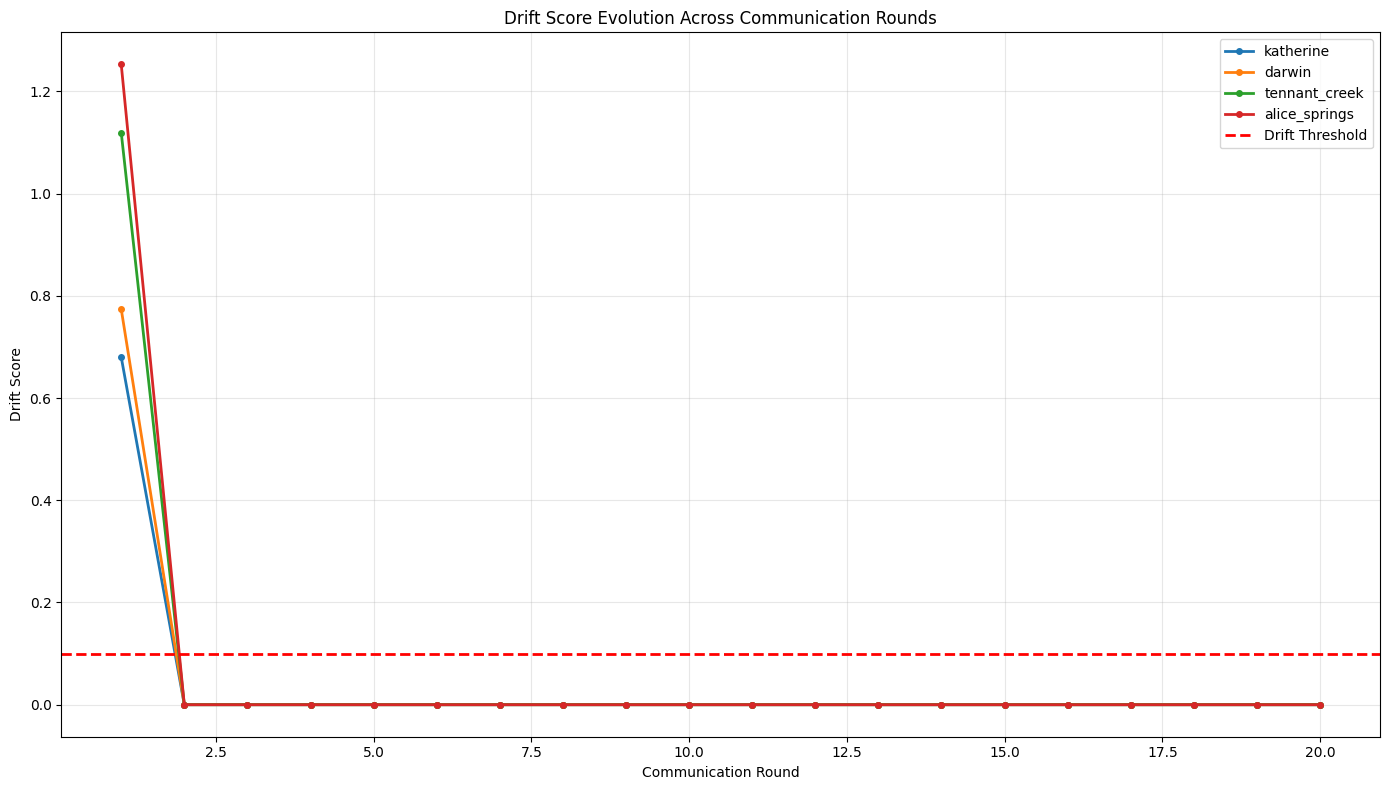

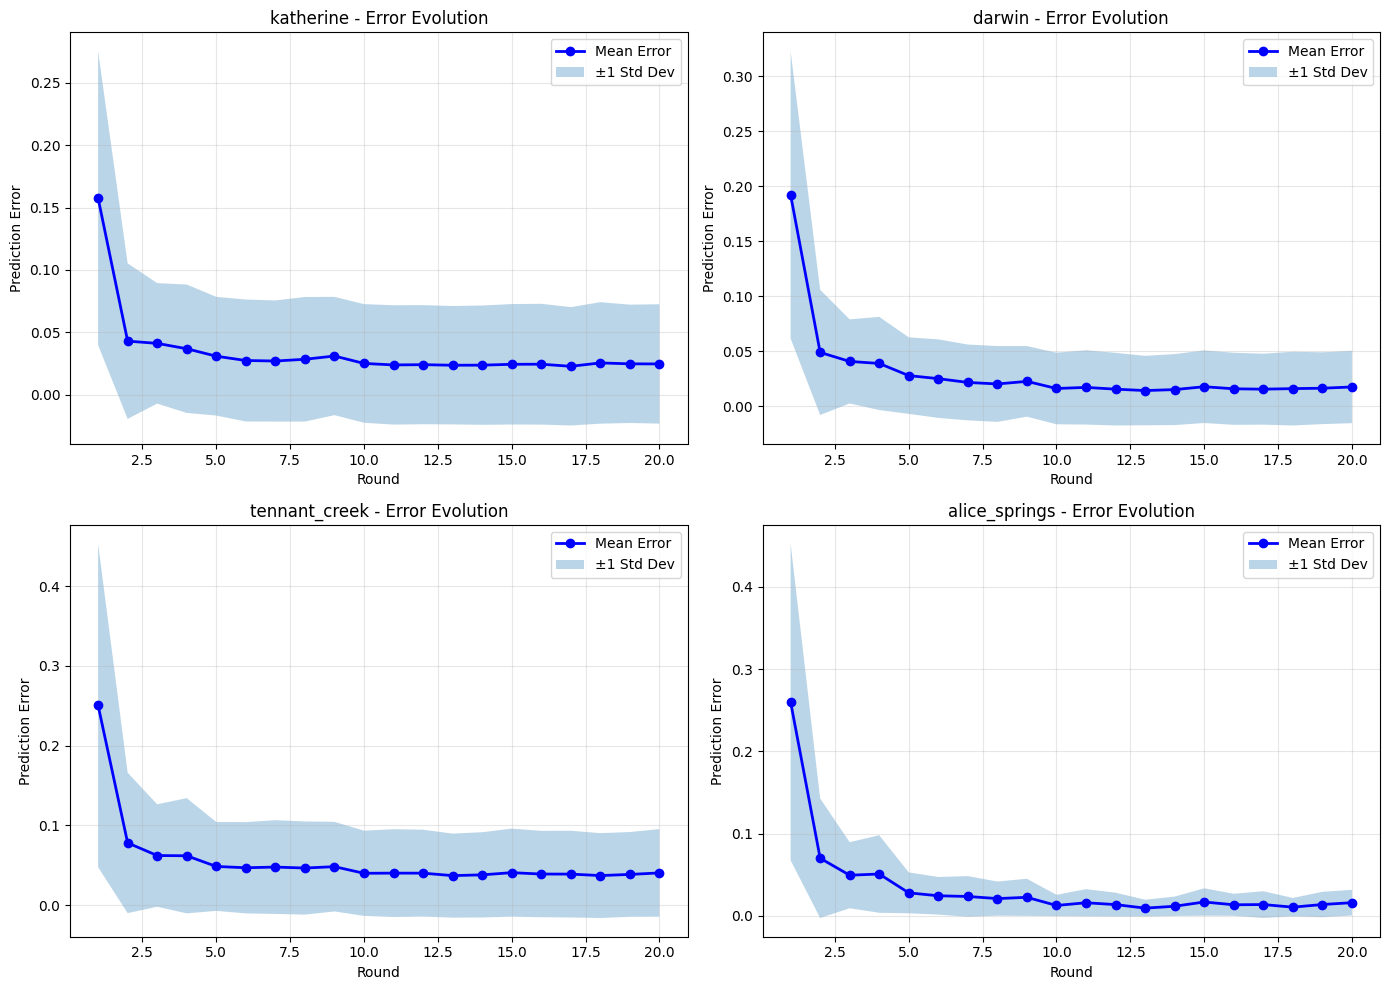

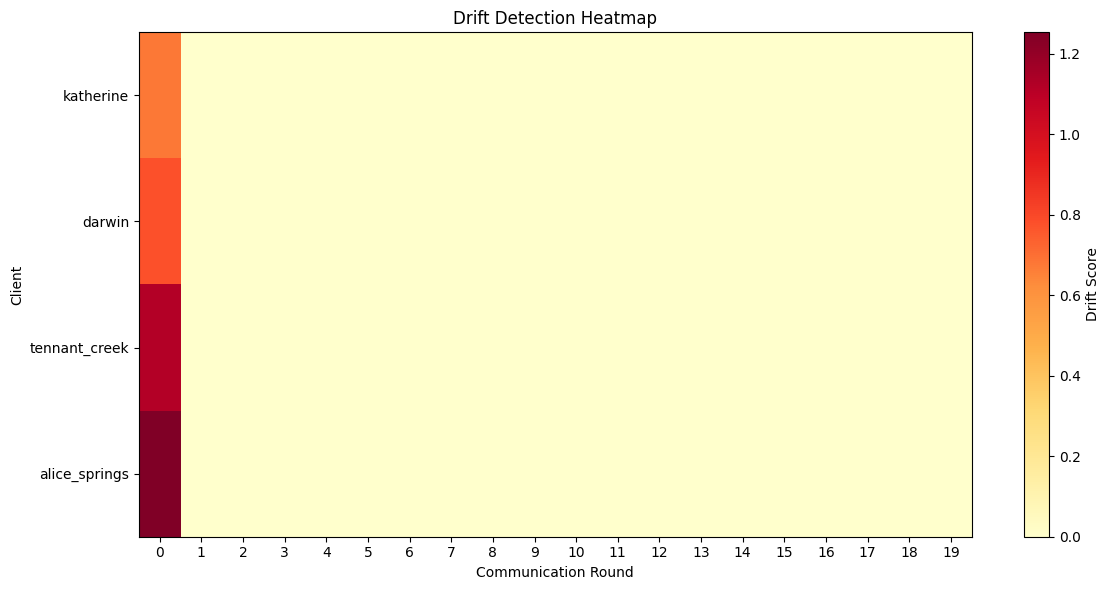


SAVING FINAL MODEL AND DRIFT HISTORY
✅ Model checkpoint saved to 'federated_model_checkpoint.pth'
✅ Global model saved to 'federated_global_model.pth'
✅ Complete drift history saved to 'drift_history_complete.pth'

📊 FINAL DRIFT DETECTION SUMMARY

  KATHERINE:
    Total drifts detected: 1/20
    Average drift score: 0.0340
    Maximum drift score: 0.6801

  DARWIN:
    Total drifts detected: 1/20
    Average drift score: 0.0387
    Maximum drift score: 0.7740

  TENNANT_CREEK:
    Total drifts detected: 1/20
    Average drift score: 0.0560
    Maximum drift score: 1.1194

  ALICE_SPRINGS:
    Total drifts detected: 1/20
    Average drift score: 0.0626
    Maximum drift score: 1.2528

🎉 FEDERATED TRAINING WITH ENHANCED DRIFT DETECTION COMPLETED!
  Total rounds: 20
  Local epochs per round: 4
  Enhanced detectors: Mean + Variance + Distribution + Concept
  Final average validation loss: 0.002238
  Total drifts detected across all clients: 4


In [30]:
# Initialize drift history tracker
drift_history_all = {loc: [] for loc in pytorch_client_data.keys()}
drift_details_history = {loc: [] for loc in pytorch_client_data.keys()}
error_evolution = {loc: [] for loc in pytorch_client_data.keys()}

for round_num in range(num_communication_rounds):
    print(f"\n{'='*60}")
    print(f"--- Communication Round {round_num + 1}/{num_communication_rounds} ---")
    print(f"{'='*60}")

    # Containers that will hold *per‑client* results of this round
    client_models_params = []        # list of state_dicts
    client_losses        = []        # avg train loss (scalar)
    client_val_losses    = []        # best val loss (scalar)
    client_sizes         = []        # # training samples (int)

    # ------------------------------------------------------------------
    # ①  LOCAL TRAINING (first pass)
    # ------------------------------------------------------------------
    print("\n📚 LOCAL TRAINING PHASE")
    print("-" * 40)
    
    for loc, client_data in pytorch_client_data.items():
        print(f"\n  Training {loc}...")
        
        # ---- instantiate a fresh copy of the global model ----
        client_model = StrongCNN(
            input_size=input_size).to(device)

        client_model.load_state_dict(global_model.state_dict())

        # ---- optimizer (L2 via weight_decay) ----
        client_optimizer = torch.optim.Adam(
            client_model.parameters(),
            lr=learning_rate,
            weight_decay=l2_lambda,
        )

        # ---- run the regular local training routine ----
        updated_params, avg_local_loss, best_val_loss = client_train_fn_regularized(
            client_model,
            client_data["train_dataloader"],
            client_data["val_dataloader"],
            client_optimizer,
            loss_fn,
            local_epochs,
            device,
            patience=1,
            l2_lambda=l2_lambda,
        )

        # ---- store the results of the first pass ----
        client_models_params.append(updated_params)
        client_losses.append(avg_local_loss)
        client_val_losses.append(best_val_loss)
        client_sizes.append(len(client_data["train_dataloader"].dataset))

        # ---- history logging (per‑client) ----
        history["client_train_losses"][loc].append(avg_local_loss)
        history["client_val_losses"][loc].append(best_val_loss)

        print(f"    ✓ {loc}: Train {avg_local_loss:.6f} | Val {best_val_loss:.6f}")

    # ------------------------------------------------------------------
    # ②  ENHANCED DRIFT DETECTION (multiple methods combined)
    # ------------------------------------------------------------------
    print("\n🔍 ENHANCED DRIFT DETECTION PHASE")
    print("-" * 40)
    
    drift_scores = {}      # raw float score per client
    drift_flags  = {}      # bool flag per client
    drift_details = {}     # detailed drift information
    drift_detected_any = False

    for loc, client_data in pytorch_client_data.items():
        val_loader = client_data["val_dataloader"]
        
        # Guard against an empty validation set
        if len(val_loader) == 0:
            print(f"  ⚠️ {loc}: Validation loader empty → assume no drift.")
            drift_scores[loc] = 0.0
            drift_flags[loc] = False
            # Store in history
            drift_history_all[loc].append(0.0)
            drift_details_history[loc].append({})
            continue

        # Get predictions for concept drift detection
        client_model = StrongCNN(input_size=input_size).to(device)
        client_model.load_state_dict(global_model.state_dict())
        client_model.eval()
        
        all_preds = []
        all_true = []
        sample_features = []
        
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)
                preds = client_model(X_batch)
                
                all_preds.append(preds.cpu().numpy())
                all_true.append(y_batch.cpu().numpy())
                sample_features.append(X_batch.cpu().numpy())
                
                # Collect enough samples for stable detection
                if len(sample_features) * X_batch.shape[0] >= 1000:
                    break
        
        if sample_features and all_preds:
            # Prepare data
            current_features = np.concatenate(sample_features, axis=0)
            all_preds = np.concatenate(all_preds, axis=0)
            all_true = np.concatenate(all_true, axis=0)
            
            # Calculate prediction errors
            errors = np.abs(all_true[:,0] - all_preds[:,0])
            error_evolution[loc].append({
                'round': round_num,
                'mean_error': np.mean(errors),
                'std_error': np.std(errors),
                'max_error': np.max(errors),
                'error_samples': errors[:1000] if len(errors) >= 1000 else errors
            })
            
            # Enhanced detection with all methods
            score, drift, details = federated_monitor.detect_client(
                loc, all_true, all_preds
            )
            
            drift_scores[loc] = score
            drift_flags[loc] = drift
            drift_details[loc] = details
            
            # Store in history
            drift_history_all[loc].append(score)
            drift_details_history[loc].append(details)
            
            if drift:
                drift_detected_any = True
                print(f"\n  🚨 DRIFT detected for {loc.upper()}!")
                print(f"      Combined score: {score:.4f}")
                print(f"      Mean shift: {details.get('mean_score', 0):.4f}")
                print(f"      Variance shift: {details.get('var_score', 0):.4f}")
                print(f"      Distribution shift: {details.get('ks_score', 0):.4f}")
                print(f"      Concept drift: {details.get('concept_score', 0):.4f}")
                print(f"      Drift votes: {details.get('drift_votes', 0)}/4")
                print(f"      Prediction error: {np.mean(errors):.4f}")
                
                # Plot drift detection for this client
                if len(errors) >= 500:
                    plt.figure(figsize=(14, 5))
                    plt.plot(errors[:1000], linewidth=1, alpha=0.7)
                    plt.axvline(
                        x=500,
                        color='red',
                        linestyle='--',
                        linewidth=3,
                        label='Detected Drift Point'
                    )
                    plt.title(f'Prediction Error Drift Detection - {loc} (Round {round_num + 1})')
                    plt.xlabel('Sample Index')
                    plt.ylabel('Absolute Error')
                    plt.legend()
                    plt.grid(True, alpha=0.3)
                    plt.tight_layout()
                    plt.show()
            else:
                print(f"  ✓ {loc}: Stable (score={score:.4f})")
        else:
            print(f"  ⚠️ {loc}: No validation samples collected")
            drift_scores[loc] = 0.0
            drift_flags[loc] = False
            drift_history_all[loc].append(0.0)
            drift_details_history[loc].append({})

    # ------------------------------------------------------------------
    # ③  ADAPTIVE RESPONSE BASED ON DRIFT TYPE
    # ------------------------------------------------------------------
    extra_local_epochs = 4

    if drift_detected_any and extra_local_epochs > 0:
        print("\n🔄 ADAPTIVE RESPONSE FOR DRIFTED CLIENTS")
        print("-" * 40)
        
        for loc, client_data in pytorch_client_data.items():
            if not drift_flags[loc]:
                continue
            
            # Get drift details for this client
            details = drift_details.get(loc, {})
            concept_score = details.get('concept_score', 0)
            ks_score = details.get('ks_score', 0)
            
            # Adjust response based on drift type and severity
            if concept_score > 0.2:
                # Severe concept drift - most aggressive response
                response_type = "🔥 SEVERE CONCEPT DRIFT"
                local_epochs_extra = 3
                dropout_rate = 0.4
                lr_factor = 2.0
                reg_factor = 3.0
            elif ks_score > 0.1:
                # Distribution shift - moderate response
                response_type = "📊 DISTRIBUTION SHIFT"
                local_epochs_extra = 2
                dropout_rate = 0.35
                lr_factor = 1.8
                reg_factor = 2.5
            else:
                # Mild drift - standard response
                response_type = "📈 MILD DRIFT"
                local_epochs_extra = 1
                dropout_rate = 0.3
                lr_factor = 1.5
                reg_factor = 2.0
            
            print(f"\n  {response_type} for {loc}")
            print(f"    Extra epochs: {local_epochs_extra}, Dropout: {dropout_rate}, LR factor: {lr_factor}")
            
            # ---- reuse the same global weights as a fresh start ----
            client_model = StrongCNN(
                input_size=input_size,
                dropout=dropout_rate,
            ).to(device)
            client_model.load_state_dict(global_model.state_dict())

            # ---- optimizer with adjusted parameters ----
            extra_optimizer = torch.optim.Adam(
                client_model.parameters(),
                lr=learning_rate * lr_factor,
                weight_decay=l2_lambda * reg_factor,
            )

            # ---- run the *additional* training ----
            _, extra_train_loss, extra_val_loss = client_train_fn_regularized(
                client_model,
                client_data["train_dataloader"],
                client_data["val_dataloader"],
                extra_optimizer,
                loss_fn,
                local_epochs_extra,
                device,
                patience=1,
                l2_lambda=l2_lambda * reg_factor,
            )

            i = list(pytorch_client_data.keys()).index(loc)
            client_models_params[i] = client_model.state_dict()
            client_losses[i] = extra_train_loss
            client_val_losses[i] = extra_val_loss

            # Also push the extra metrics into the history
            history["client_train_losses"][loc].append(extra_train_loss)
            history["client_val_losses"][loc].append(extra_val_loss)

            print(f"    ✓ Extra training complete: Train {extra_train_loss:.6f} | Val {extra_val_loss:.6f}")

    # ------------------------------------------------------------------
    # ④  DRIFT‑AWARE AGGREGATION (weighted FedAvg)
    # ------------------------------------------------------------------
    print("\n⚖️  FEDERATED AGGREGATION PHASE")
    print("-" * 40)
    
    # Base weights are proportional to the amount of training data
    total_samples = sum(client_sizes)
    base_weights = [size / total_samples for size in client_sizes]

    adjusted_weights = []
    for loc, bw in zip(pytorch_client_data.keys(), base_weights):
        w_adj = drift_weight_enhanced(
            score=drift_scores[loc],
            drift_flag=drift_flags[loc],
            base_weight=bw
        )
        adjusted_weights.append(w_adj)
        print(f"  {loc}: Base weight={bw:.4f} → Adjusted={w_adj:.4f} (score={drift_scores[loc]:.4f})")

    # Normalise so that they sum to 1
    weight_sum = sum(adjusted_weights)
    if weight_sum == 0:
        # Fallback to uniform weights
        adjusted_weights = [1.0 / len(adjusted_weights)] * len(adjusted_weights)
        print("  ⚠️ Using uniform weights (fallback)")
    else:
        adjusted_weights = [w / weight_sum for w in adjusted_weights]
        print(f"  Normalized weights sum: {sum(adjusted_weights):.4f}")

    # Perform the weighted FedAvg using the *adjusted* weights
    aggregated_params = {}
    for key in client_models_params[0].keys():
        if torch.is_floating_point(client_models_params[0][key]):
            weighted_sum = torch.zeros_like(client_models_params[0][key])
            for w, p in zip(adjusted_weights, client_models_params):
                weighted_sum += w * p[key]
            aggregated_params[key] = weighted_sum
        else:
            # Non-float tensors - just copy from first client
            aggregated_params[key] = client_models_params[0][key].clone()

    # Update the global model for the next round
    global_model.load_state_dict(aggregated_params)
    print("  ✓ Global model updated with drift-aware aggregation")

    # ------------------------------------------------------------------
    # ⑤  ROUND‑LEVEL LOGGING (global metrics)
    # ------------------------------------------------------------------
    print("\n📊 ROUND SUMMARY")
    print("-" * 40)
    
    avg_round_loss = np.mean(client_losses)
    avg_round_val = np.mean(client_val_losses)
    
    # Weighted averages
    weighted_avg_loss = sum(w * l for w, l in zip(adjusted_weights, client_losses))
    weighted_avg_val = sum(w * v for w, v in zip(adjusted_weights, client_val_losses))

    history["global_train_loss"].append(avg_round_loss)
    history["global_val_loss"].append(avg_round_val)

    print(f"  Average Train Loss: {avg_round_loss:.6f}")
    print(f"  Average Val Loss:   {avg_round_val:.6f}")
    print(f"  Weighted Train Loss: {weighted_avg_loss:.6f}")
    print(f"  Weighted Val Loss:   {weighted_avg_val:.6f}")
    
    # Drift summary
    n_drifted = sum(drift_flags.values())
    avg_drift_score = np.mean(list(drift_scores.values())) if drift_scores else 0
    print(f"  Drifted clients: {n_drifted}/{len(pytorch_client_data)}")
    print(f"  Average drift score: {avg_drift_score:.4f}")
    
    if avg_round_val > 1.5 * avg_round_loss:
        print("  ⚠️  Possible overfitting (Val > 1.5× Train)")
    elif avg_round_val > 1.2 * avg_round_loss:
        print("  ⚠️  Mild overfitting detected")
    else:
        print("  ✓ Training and validation losses are balanced")
    
    print(f"\n✅ Round {round_num + 1} completed successfully")

# ------------------------------------------------------------------
# ⑥  FINAL DRIFT ANALYSIS AND PLOTS
# ------------------------------------------------------------------
print("\n" + "="*60)
print("FINAL DRIFT ANALYSIS AND VISUALIZATION")
print("="*60)

# Plot drift scores over rounds for all clients
plt.figure(figsize=(14, 8))

for loc, drift_scores in drift_history_all.items():
    if drift_scores:
        plt.plot(range(1, len(drift_scores) + 1), drift_scores, 
                marker='o', linewidth=2, label=loc, markersize=4)

plt.axhline(y=0.1, color='red', linestyle='--', linewidth=2, label='Drift Threshold')
plt.xlabel('Communication Round')
plt.ylabel('Drift Score')
plt.title('Drift Score Evolution Across Communication Rounds')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot error evolution for each client
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, loc in enumerate(error_evolution.keys()):
    if error_evolution[loc]:
        errors_data = error_evolution[loc]
        rounds = [e['round'] + 1 for e in errors_data]
        mean_errors = [e['mean_error'] for e in errors_data]
        std_errors = [e['std_error'] for e in errors_data]
        
        axes[idx].plot(rounds, mean_errors, 'b-o', linewidth=2, markersize=6, label='Mean Error')
        axes[idx].fill_between(rounds, 
                                [m - s for m, s in zip(mean_errors, std_errors)],
                                [m + s for m, s in zip(mean_errors, std_errors)],
                                alpha=0.3, label='±1 Std Dev')
        axes[idx].set_xlabel('Round')
        axes[idx].set_ylabel('Prediction Error')
        axes[idx].set_title(f'{loc} - Error Evolution')
        axes[idx].legend()
        axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Plot drift severity heatmap
drift_matrix = []
client_names = []
for loc in drift_history_all.keys():
    if drift_history_all[loc]:
        drift_matrix.append(drift_history_all[loc])
        client_names.append(loc)

if drift_matrix:
    plt.figure(figsize=(12, 6))
    im = plt.imshow(drift_matrix, cmap='YlOrRd', aspect='auto', interpolation='nearest')
    plt.colorbar(im, label='Drift Score')
    plt.xlabel('Communication Round')
    plt.ylabel('Client')
    plt.title('Drift Detection Heatmap')
    plt.yticks(range(len(client_names)), client_names)
    plt.xticks(range(num_communication_rounds))
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------------
# ⑦  SAVE FINAL MODEL AND DRIFT HISTORY
# ------------------------------------------------------------------
print("\n" + "="*60)
print("SAVING FINAL MODEL AND DRIFT HISTORY")
print("="*60)

checkpoint = {
    "model_state_dict": global_model.state_dict(),
    "input_size": input_size,
    "model_name": "StrongCNN",
    "num_rounds": num_communication_rounds,
    "local_epochs": local_epochs,
    "drift_method": "ENHANCED_HYBRID",
    "drift_threshold": 0.1,
    "final_drift_scores": drift_scores,
    "final_drift_details": {k: v for k, v in drift_details.items() if v}
}

torch.save(checkpoint, "federated_model_checkpoint.pth")
print("✅ Model checkpoint saved to 'federated_model_checkpoint.pth'")

torch.save(global_model.state_dict(), "federated_global_model.pth")
print("✅ Global model saved to 'federated_global_model.pth'")

# Save comprehensive drift history
drift_history_complete = {
    "per_round_scores": drift_history_all,
    "per_round_details": drift_details_history,
    "error_evolution": error_evolution,
    "total_drifts_per_client": {loc: sum(1 for s in scores if s > 0.1) 
                                 for loc, scores in drift_history_all.items()},
    "avg_drift_score_per_client": {loc: np.mean(scores) if scores else 0 
                                    for loc, scores in drift_history_all.items()}
}

torch.save(drift_history_complete, "drift_history_complete.pth")
print("✅ Complete drift history saved to 'drift_history_complete.pth'")

# Print final drift summary
print("\n" + "="*60)
print("📊 FINAL DRIFT DETECTION SUMMARY")
print("="*60)

for loc in drift_history_all.keys():
    scores = drift_history_all[loc]
    if scores:
        total_drifts = sum(1 for s in scores if s > 0.1)
        avg_score = np.mean(scores)
        max_score = np.max(scores)
        print(f"\n  {loc.upper()}:")
        print(f"    Total drifts detected: {total_drifts}/{num_communication_rounds}")
        print(f"    Average drift score: {avg_score:.4f}")
        print(f"    Maximum drift score: {max_score:.4f}")

print("\n" + "="*60)
print("🎉 FEDERATED TRAINING WITH ENHANCED DRIFT DETECTION COMPLETED!")
print("="*60)
print(f"  Total rounds: {num_communication_rounds}")
print(f"  Local epochs per round: {local_epochs}")
print(f"  Enhanced detectors: Mean + Variance + Distribution + Concept")
print(f"  Final average validation loss: {avg_round_val:.6f}")
print(f"  Total drifts detected across all clients: {sum(drift_history_complete['total_drifts_per_client'].values())}")
print("="*60)

# Drift detect graph

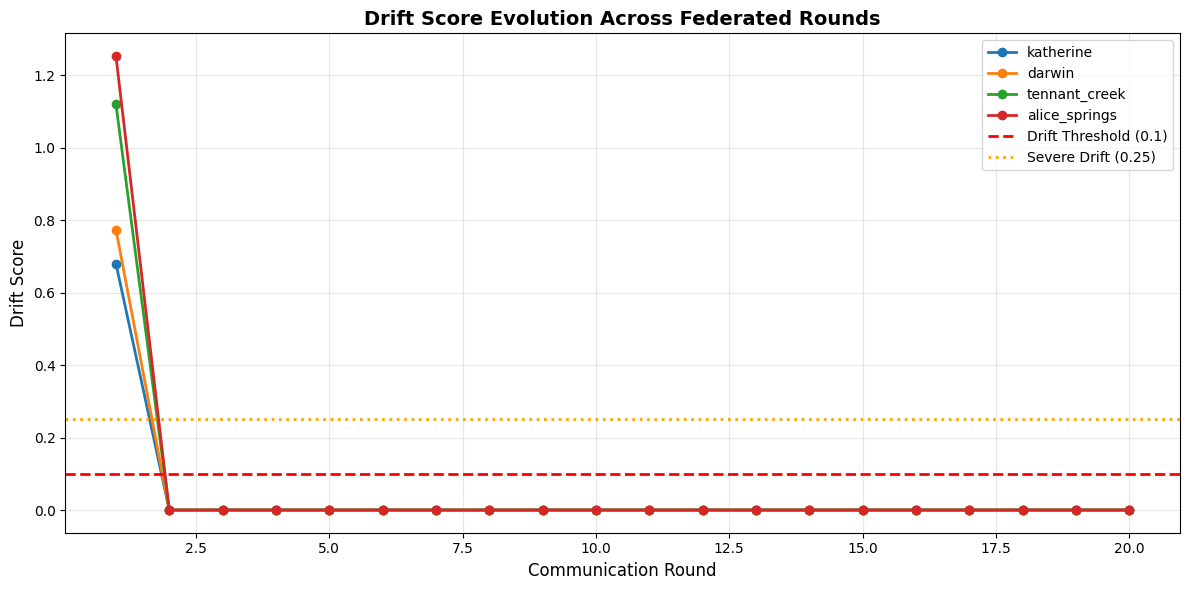

✅ Saved: drift_score_evolution_20260521_132434.png/pdf


/tmp/ipykernel_23/2224567228.py:70: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper right', fontsize=10)


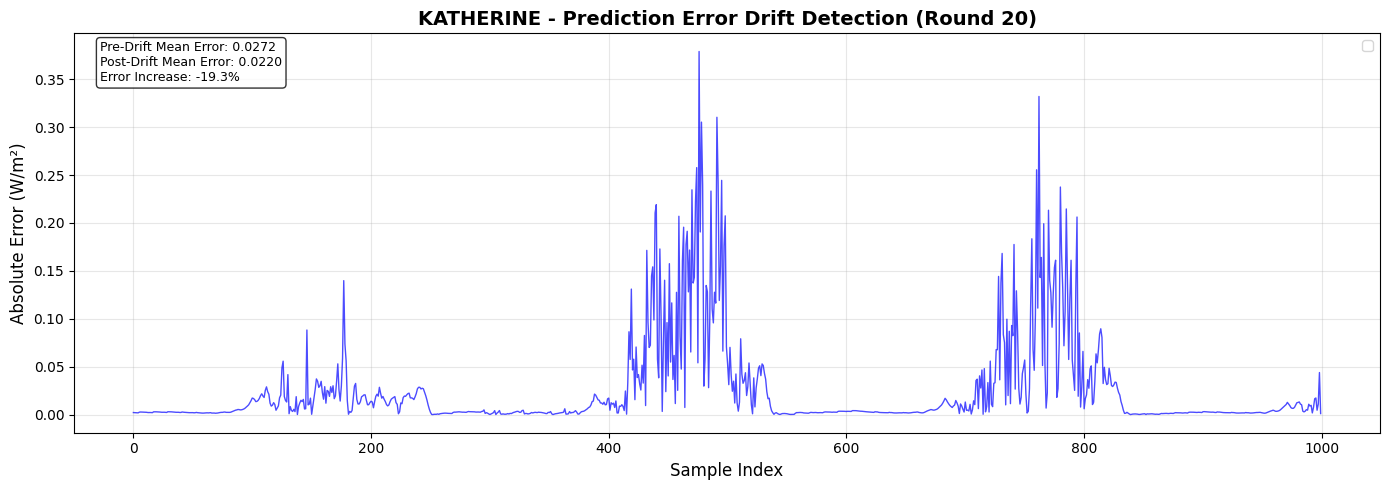

✅ Saved: katherine_error_drift_detection_20260521_132434.png/pdf


/tmp/ipykernel_23/2224567228.py:70: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper right', fontsize=10)


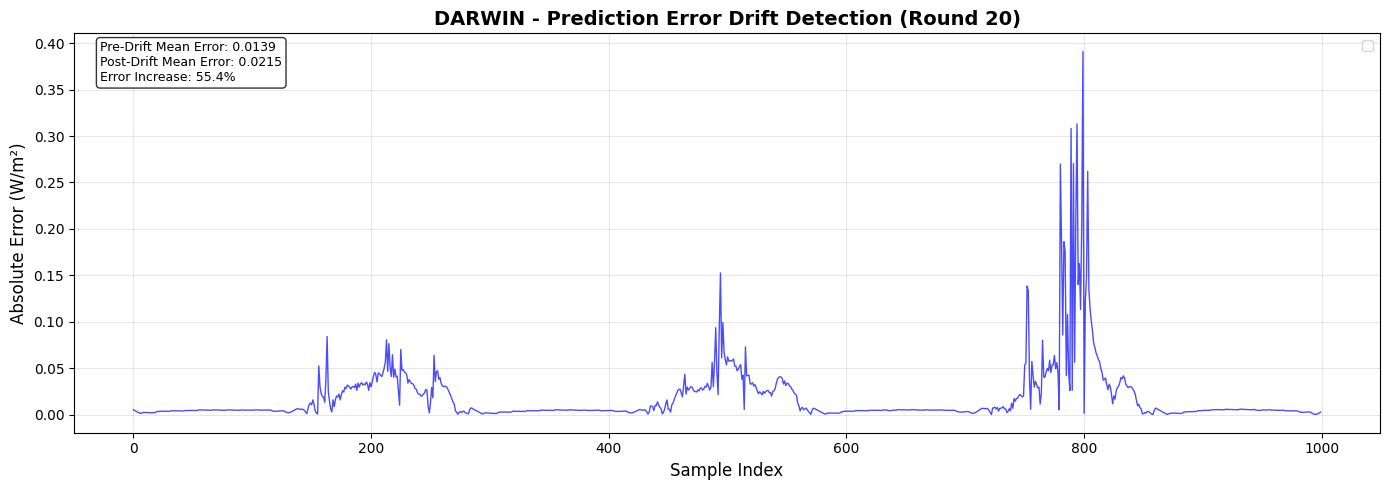

✅ Saved: darwin_error_drift_detection_20260521_132434.png/pdf


/tmp/ipykernel_23/2224567228.py:70: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper right', fontsize=10)


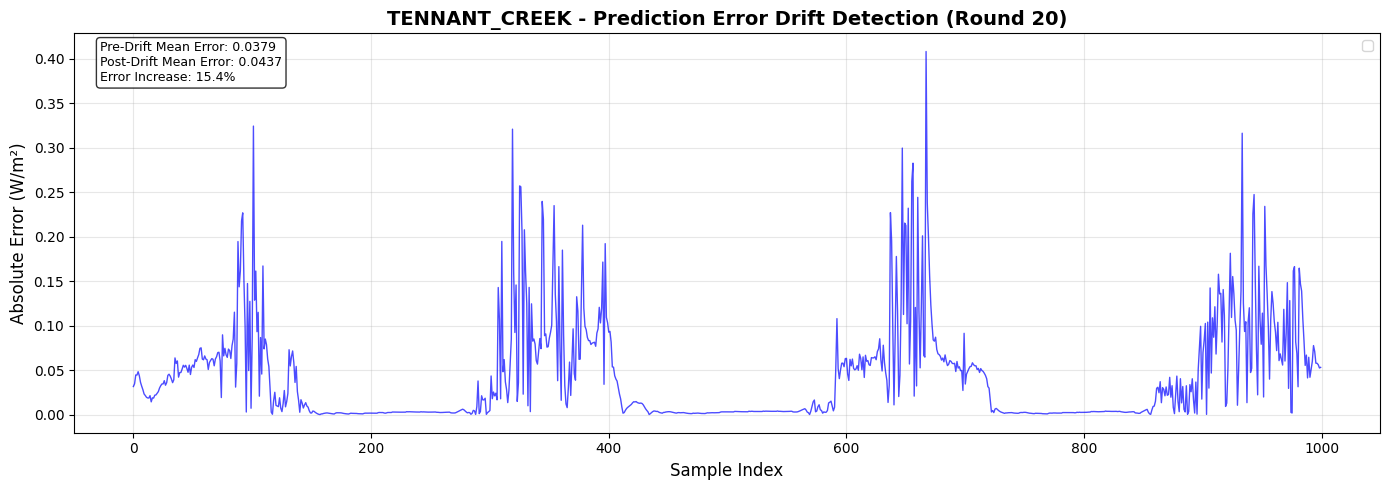

✅ Saved: tennant_creek_error_drift_detection_20260521_132434.png/pdf


/tmp/ipykernel_23/2224567228.py:70: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper right', fontsize=10)


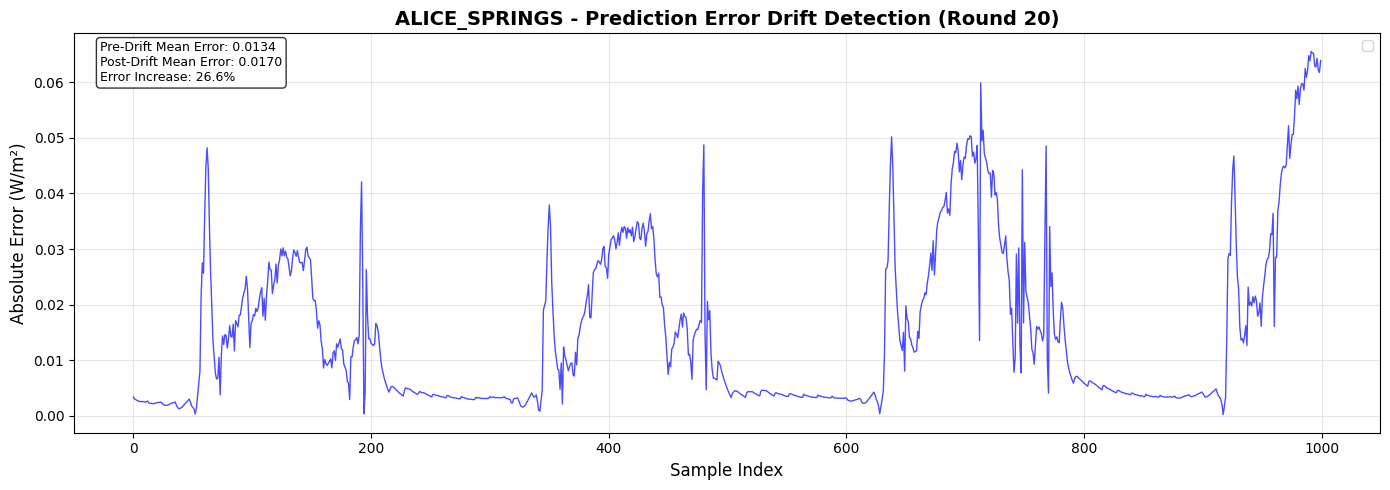

✅ Saved: alice_springs_error_drift_detection_20260521_132434.png/pdf


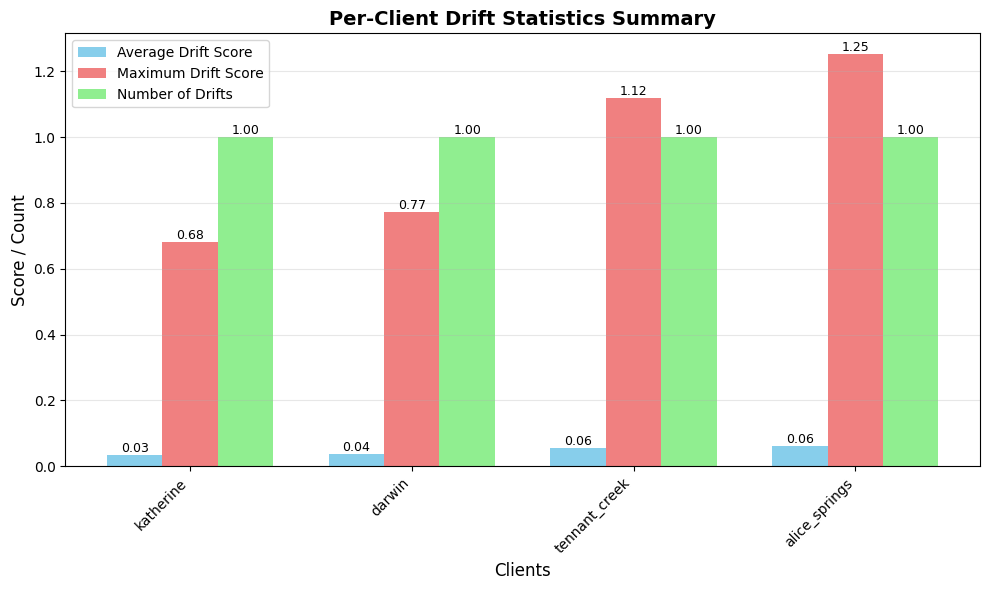

✅ Saved: client_drift_summary_20260521_132434.png/pdf


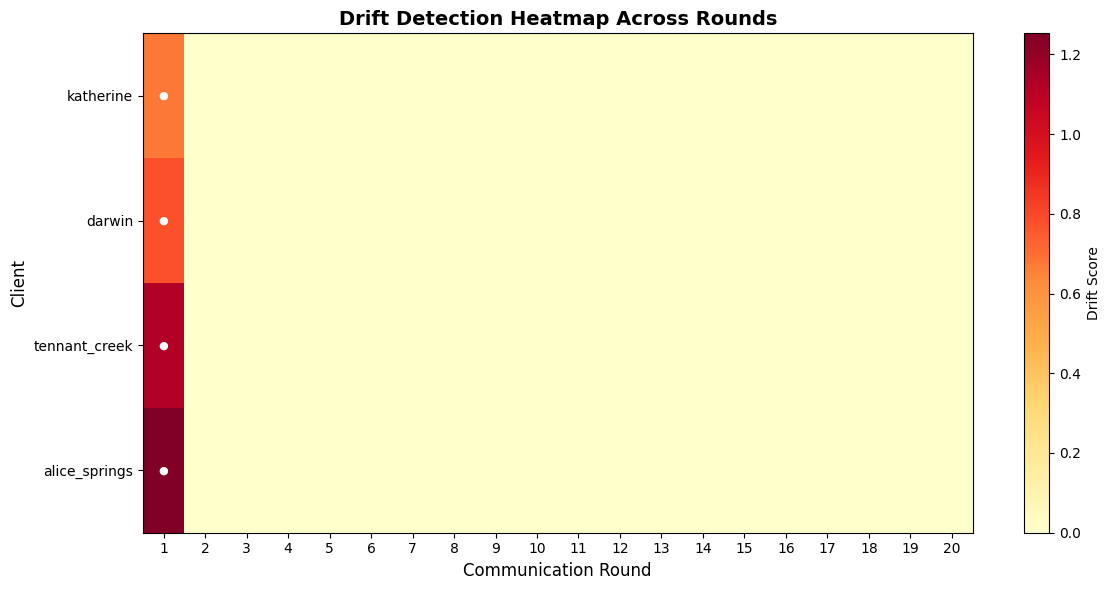

✅ Saved: drift_heatmap_20260521_132434.png/pdf


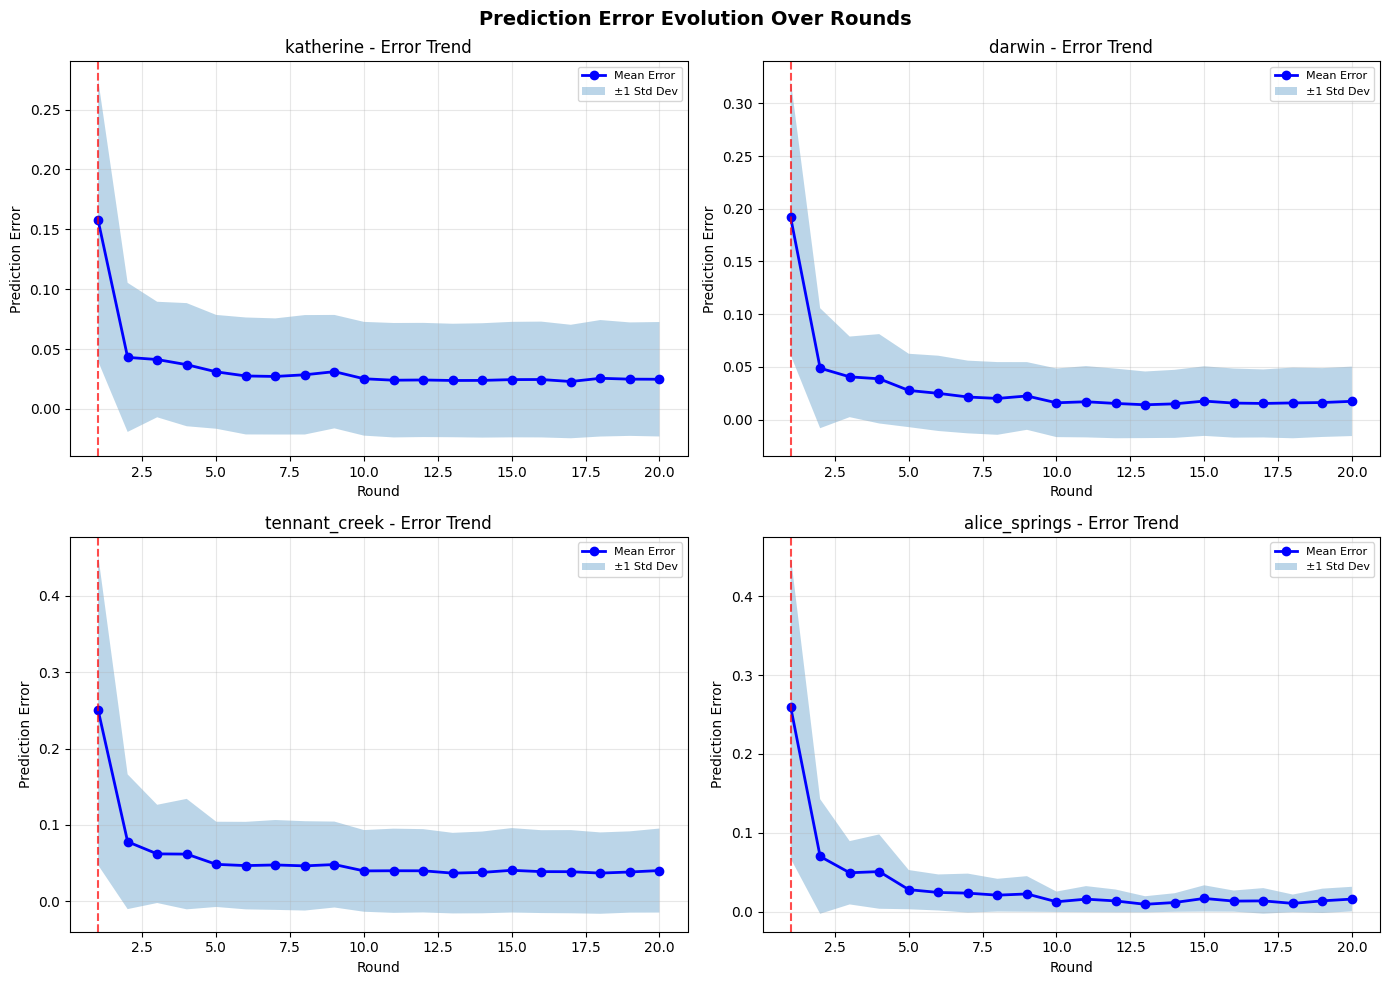

✅ Saved: error_trend_over_rounds_20260521_132434.png/pdf

📁 SAVED DRIFT ANALYSIS PLOTS

Directory: drift_analysis_plots/

Files saved:
  1. drift_score_evolution_20260521_132434.png/pdf
  2. [client]_error_drift_detection_20260521_132434.png/pdf (one per client)
  3. client_drift_summary_20260521_132434.png/pdf
  4. drift_heatmap_20260521_132434.png/pdf
  5. error_trend_over_rounds_20260521_132434.png/pdf

✅ All plots saved successfully!


In [31]:
import os
from datetime import datetime

# Create directory for saving plots
plot_dir = "drift_analysis_plots"
os.makedirs(plot_dir, exist_ok=True)
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# ==============================================================
# PLOT 1: Drift Score Evolution (Independent)
# ==============================================================
plt.figure(figsize=(12, 6))

for loc, scores in drift_history_all.items():
    if scores:
        rounds = range(1, len(scores) + 1)
        plt.plot(rounds, scores, marker='o', linewidth=2, 
                markersize=6, label=loc)

# Add threshold lines
plt.axhline(y=0.1, color='red', linestyle='--', linewidth=2, 
           label='Drift Threshold (0.1)')
plt.axhline(y=0.25, color='orange', linestyle=':', linewidth=2, 
           label='Severe Drift (0.25)')

plt.title('Drift Score Evolution Across Federated Rounds', fontsize=14, fontweight='bold')
plt.xlabel('Communication Round', fontsize=12)
plt.ylabel('Drift Score', fontsize=12)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)

# Save independent plot
plt.tight_layout()
plt.savefig(f"{plot_dir}/drift_score_evolution_{timestamp}.png", dpi=300, bbox_inches='tight')
plt.savefig(f"{plot_dir}/drift_score_evolution_{timestamp}.pdf", bbox_inches='tight')
plt.show()
plt.close()  # Close to free memory

print(f"✅ Saved: drift_score_evolution_{timestamp}.png/pdf")

# ==============================================================
# PLOT 2: Prediction Error with Drift Detection (Independent)
# ==============================================================

for loc in pytorch_client_data.keys():
    # Get the latest error data for this client
    if loc in error_evolution and error_evolution[loc]:
        latest_errors = error_evolution[loc][-1]['error_samples']
        
        plt.figure(figsize=(14, 5))
        
        # Plot error stream
        plt.plot(latest_errors[:1000], linewidth=1, color='blue', alpha=0.7)
        
        # Add drift detection line if drift was detected
        if loc in drift_flags and drift_flags[loc]:
            # Find where drift was detected in this round
            drift_point = 500  # You can make this dynamic based on your detection
            plt.axvline(x=drift_point, color='red', linestyle='--', 
                       linewidth=3, label='Detected Drift Point')
            
            # Add shaded regions to show before/after drift
            plt.axvspan(0, drift_point, alpha=0.1, color='green', label='Pre-Drift')
            plt.axvspan(drift_point, 1000, alpha=0.1, color='red', label='Post-Drift')
        
        plt.title(f'{loc.upper()} - Prediction Error Drift Detection (Round {num_communication_rounds})', 
                 fontsize=14, fontweight='bold')
        plt.xlabel('Sample Index', fontsize=12)
        plt.ylabel('Absolute Error (W/m²)', fontsize=12)
        plt.legend(loc='upper right', fontsize=10)
        plt.grid(True, alpha=0.3)
        
        # Add statistics box
        pre_drift_errors = latest_errors[:500] if len(latest_errors) > 500 else latest_errors
        post_drift_errors = latest_errors[500:1000] if len(latest_errors) > 1000 else latest_errors[500:]
        
        stats_text = f'Pre-Drift Mean Error: {np.mean(pre_drift_errors):.4f}\n'
        stats_text += f'Post-Drift Mean Error: {np.mean(post_drift_errors):.4f}\n'
        stats_text += f'Error Increase: {((np.mean(post_drift_errors) - np.mean(pre_drift_errors)) / np.mean(pre_drift_errors) * 100):.1f}%'
        
        plt.text(0.02, 0.98, stats_text, transform=plt.gca().transAxes,
                fontsize=9, verticalalignment='top',
                bbox=dict(boxstyle="round", facecolor='white', alpha=0.8))
        
        # Save independent plot for each client
        plt.tight_layout()
        plt.savefig(f"{plot_dir}/{loc}_error_drift_detection_{timestamp}.png", dpi=300, bbox_inches='tight')
        plt.savefig(f"{plot_dir}/{loc}_error_drift_detection_{timestamp}.pdf", bbox_inches='tight')
        plt.show()
        plt.close()
        
        print(f"✅ Saved: {loc}_error_drift_detection_{timestamp}.png/pdf")

# ==============================================================
# PLOT 3: Per-Client Drift Score Comparison (Independent)
# ==============================================================
plt.figure(figsize=(10, 6))

# Prepare data for bar chart
clients = list(drift_history_all.keys())
avg_drift_scores = [np.mean(drift_history_all[loc]) if drift_history_all[loc] else 0 for loc in clients]
max_drift_scores = [np.max(drift_history_all[loc]) if drift_history_all[loc] else 0 for loc in clients]
drift_counts = [sum(1 for s in drift_history_all[loc] if s > 0.1) if drift_history_all[loc] else 0 for loc in clients]

x = np.arange(len(clients))
width = 0.25

# Create bars
bars1 = plt.bar(x - width, avg_drift_scores, width, label='Average Drift Score', color='skyblue')
bars2 = plt.bar(x, max_drift_scores, width, label='Maximum Drift Score', color='lightcoral')
bars3 = plt.bar(x + width, drift_counts, width, label='Number of Drifts', color='lightgreen')

plt.xlabel('Clients', fontsize=12)
plt.ylabel('Score / Count', fontsize=12)
plt.title('Per-Client Drift Statistics Summary', fontsize=14, fontweight='bold')
plt.xticks(x, clients, rotation=45, ha='right')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(f"{plot_dir}/client_drift_summary_{timestamp}.png", dpi=300, bbox_inches='tight')
plt.savefig(f"{plot_dir}/client_drift_summary_{timestamp}.pdf", bbox_inches='tight')
plt.show()
plt.close()

print(f"✅ Saved: client_drift_summary_{timestamp}.png/pdf")

# ==============================================================
# PLOT 4: Drift Heatmap (Independent)
# ==============================================================
if drift_history_all:
    # Prepare matrix for heatmap
    drift_matrix = []
    client_names = []
    
    for loc in clients:
        if drift_history_all[loc]:
            drift_matrix.append(drift_history_all[loc])
            client_names.append(loc)
    
    if drift_matrix:
        plt.figure(figsize=(12, 6))
        
        # Create heatmap
        im = plt.imshow(drift_matrix, cmap='YlOrRd', aspect='auto', interpolation='nearest')
        
        # Add colorbar
        cbar = plt.colorbar(im, label='Drift Score')
        
        plt.xlabel('Communication Round', fontsize=12)
        plt.ylabel('Client', fontsize=12)
        plt.title('Drift Detection Heatmap Across Rounds', fontsize=14, fontweight='bold')
        
        # Set ticks
        plt.xticks(range(num_communication_rounds), range(1, num_communication_rounds + 1))
        plt.yticks(range(len(client_names)), client_names)
        
        # Add text annotations
        for i in range(len(client_names)):
            for j in range(len(drift_matrix[0])):
                if drift_matrix[i][j] > 0.25:  # Severe drift
                    plt.text(j, i, '●', ha='center', va='center', color='white', fontsize=8)
                elif drift_matrix[i][j] > 0.1:  # Moderate drift
                    plt.text(j, i, '○', ha='center', va='center', color='black', fontsize=8)
        
        plt.tight_layout()
        plt.savefig(f"{plot_dir}/drift_heatmap_{timestamp}.png", dpi=300, bbox_inches='tight')
        plt.savefig(f"{plot_dir}/drift_heatmap_{timestamp}.pdf", bbox_inches='tight')
        plt.show()
        plt.close()
        
        print(f"✅ Saved: drift_heatmap_{timestamp}.png/pdf")

# ==============================================================
# PLOT 5: Error Trend Over Rounds (Independent)
# ==============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, loc in enumerate(error_evolution.keys()):
    if idx < 4:  # Handle up to 4 clients
        if error_evolution[loc]:
            errors_data = error_evolution[loc]
            rounds = [e['round'] + 1 for e in errors_data]
            mean_errors = [e['mean_error'] for e in errors_data]
            std_errors = [e['std_error'] for e in errors_data]
            
            axes[idx].plot(rounds, mean_errors, 'b-o', linewidth=2, markersize=6, label='Mean Error')
            axes[idx].fill_between(rounds, 
                                    [m - s for m, s in zip(mean_errors, std_errors)],
                                    [m + s for m, s in zip(mean_errors, std_errors)],
                                    alpha=0.3, label='±1 Std Dev')
            
            # Mark where drift occurred
            if loc in drift_history_all and drift_history_all[loc]:
                drift_rounds = [i+1 for i, s in enumerate(drift_history_all[loc]) if s > 0.1]
                if drift_rounds:
                    for dr in drift_rounds:
                        axes[idx].axvline(x=dr, color='red', linestyle='--', 
                                        alpha=0.7, linewidth=1.5)
            
            axes[idx].set_xlabel('Round', fontsize=10)
            axes[idx].set_ylabel('Prediction Error', fontsize=10)
            axes[idx].set_title(f'{loc} - Error Trend', fontsize=12)
            axes[idx].legend(fontsize=8)
            axes[idx].grid(True, alpha=0.3)

plt.suptitle('Prediction Error Evolution Over Rounds', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{plot_dir}/error_trend_over_rounds_{timestamp}.png", dpi=300, bbox_inches='tight')
plt.savefig(f"{plot_dir}/error_trend_over_rounds_{timestamp}.pdf", bbox_inches='tight')
plt.show()
plt.close()

print(f"✅ Saved: error_trend_over_rounds_{timestamp}.png/pdf")

# ==============================================================
# SUMMARY OF SAVED FILES
# ==============================================================
print("\n" + "="*60)
print("📁 SAVED DRIFT ANALYSIS PLOTS")
print("="*60)
print(f"\nDirectory: {plot_dir}/")
print("\nFiles saved:")
print(f"  1. drift_score_evolution_{timestamp}.png/pdf")
print(f"  2. [client]_error_drift_detection_{timestamp}.png/pdf (one per client)")
print(f"  3. client_drift_summary_{timestamp}.png/pdf")
print(f"  4. drift_heatmap_{timestamp}.png/pdf")
print(f"  5. error_trend_over_rounds_{timestamp}.png/pdf")
print(f"\n✅ All plots saved successfully!")


# Plot Loss Graph

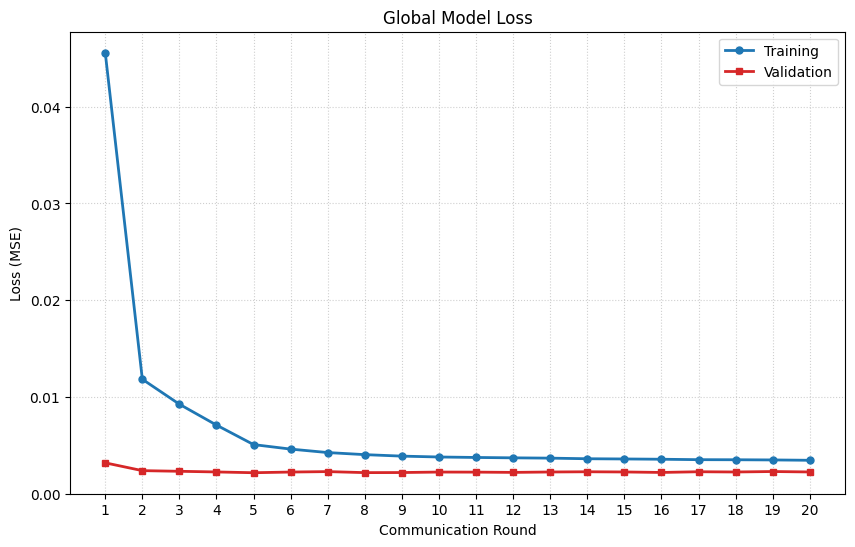

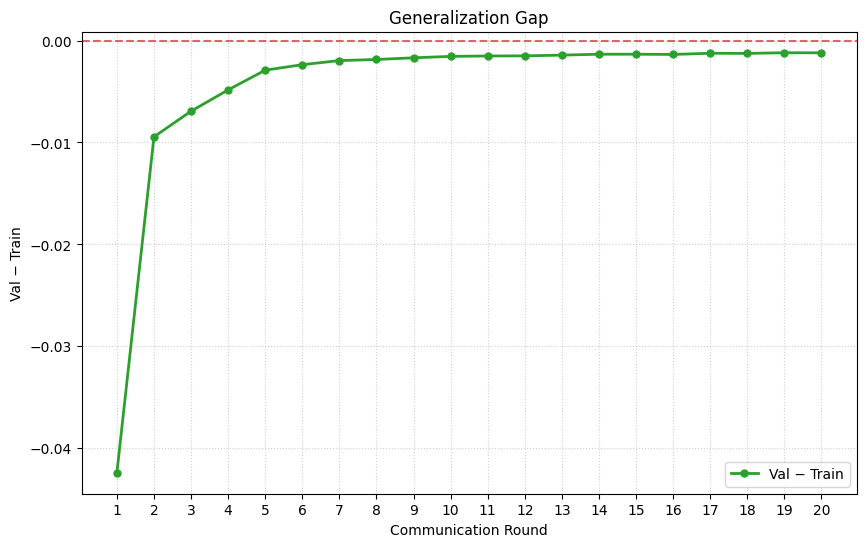

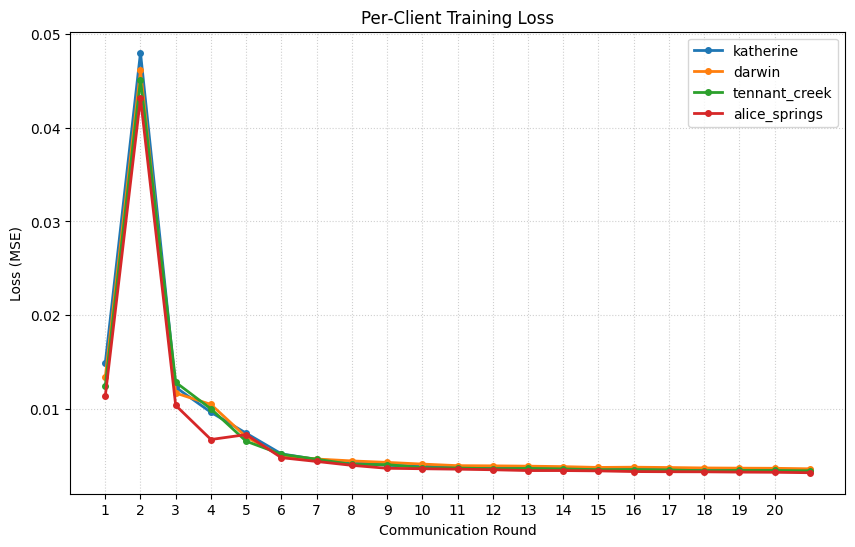

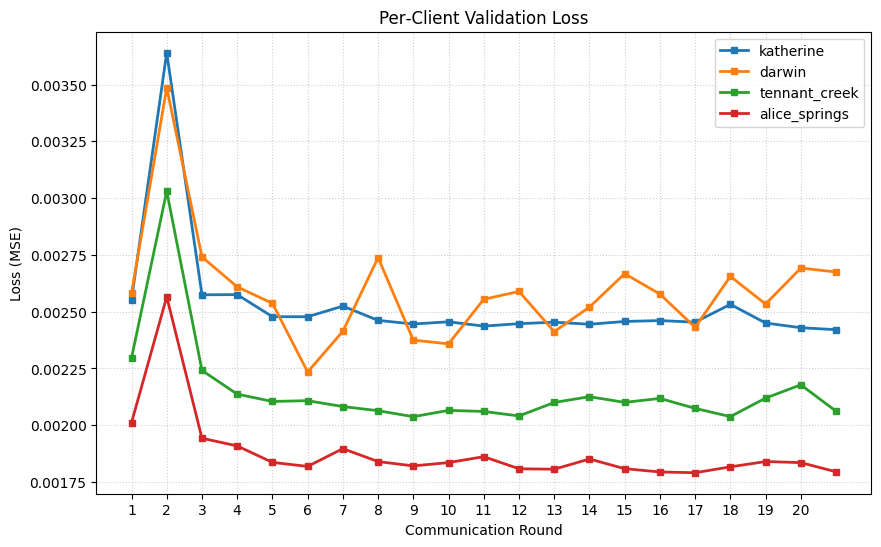

In [32]:
import os
import numpy as np
import matplotlib.pyplot as plt

# Create a folder to store figures
save_dir = "figures"
os.makedirs(save_dir, exist_ok=True)

comm_rounds = np.arange(1, len(history["global_train_loss"]) + 1)

# ----- GLOBAL TRAIN vs VAL -----
plt.figure(figsize=(10,6))
plt.plot(comm_rounds, history["global_train_loss"], marker="o", color="tab:blue", linewidth=2, markersize=5, label="Training")
plt.plot(comm_rounds, history["global_val_loss"], marker="s", color="tab:red", linewidth=2, markersize=5, label="Validation")
plt.xlabel("Communication Round")
plt.ylabel("Loss (MSE)")
plt.title("Global Model Loss")
plt.xticks(comm_rounds)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()
plt.savefig(os.path.join(save_dir, "global_loss.png"), dpi=300, bbox_inches="tight")
plt.show()

# ----- GENERALIZATION GAP -----
plt.figure(figsize=(10,6))
gap = np.array(history["global_val_loss"]) - np.array(history["global_train_loss"])
plt.plot(comm_rounds, gap, marker="o", color="tab:green", linewidth=2, markersize=5, label="Val − Train")
plt.axhline(0, color="tab:red", linestyle="--", linewidth=1.5, alpha=0.7)
plt.xlabel("Communication Round")
plt.ylabel("Val − Train")
plt.title("Generalization Gap")
plt.xticks(comm_rounds)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()
plt.savefig(os.path.join(save_dir, "generalization_gap.png"), dpi=300, bbox_inches="tight")
plt.show()

# ----- PER‑CLIENT TRAINING LOSS -----
plt.figure(figsize=(10,6))
for loc, losses in history["client_train_losses"].items():
    client_rounds = np.arange(1, len(losses) + 1)
    plt.plot(client_rounds, losses, marker="o", linewidth=2, markersize=4, label=loc)
plt.xlabel("Communication Round")
plt.ylabel("Loss (MSE)")
plt.title("Per‑Client Training Loss")
plt.xticks(comm_rounds)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()
plt.savefig(os.path.join(save_dir, "client_train_loss.png"), dpi=300, bbox_inches="tight")
plt.show()

# ----- PER‑CLIENT VALIDATION LOSS -----
plt.figure(figsize=(10,6))
for loc, losses in history["client_val_losses"].items():
    client_rounds = np.arange(1, len(losses) + 1)
    plt.plot(client_rounds, losses, marker="s", linewidth=2, markersize=4, label=loc)
plt.xlabel("Communication Round")
plt.ylabel("Loss (MSE)")
plt.title("Per‑Client Validation Loss")
plt.xticks(comm_rounds)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()
plt.savefig(os.path.join(save_dir, "client_val_loss.png"), dpi=300, bbox_inches="tight")
plt.show()

# Test Evaluation

In [33]:
# --------------------------------------------------------------
# 3️⃣  Final test evaluation – guard against empty test loaders
# --------------------------------------------------------------

def evaluate_on_loader(model, loader):                        # turn off dropout / batch‑norm updates
    total_loss = 0.0
    total_samples = 0

    with torch.no_grad():                     # no gradient tracking
        for X_batch, y_batch in loader:
            # ---------------------------------------------------------
            # Move the batch to the correct device (CPU or GPU)
            # ---------------------------------------------------------
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            # Forward pass
            preds = model(X_batch)

            # Compute loss (reduction='mean' is default for MSELoss)
            loss = loss_fn(preds, y_batch)

            # Accumulate loss * number of samples in this batch
            batch_sz = X_batch.size(0)
            total_loss += loss.item() * batch_sz
            total_samples += batch_sz

    # Guard against division by zero (empty loader)
    if total_samples == 0:
        return float('nan')

    avg_loss = total_loss / total_samples
    return avg_loss


global_model.load_state_dict(torch.load('federated_global_model.pth', map_location=device))
global_model.eval()

test_losses = []
for loc, client_data in pytorch_client_data.items():
    test_loader = client_data["test_dataloader"]
    if len(test_loader) == 0:
        print(f"⚠️  Test loader for {loc} is empty – appending NaN.")
        test_losses.append(np.nan)
        continue

    loss = evaluate_on_loader(global_model, test_loader)
    test_losses.append(loss)
    print(f"Client {loc} – Test loss: {loss:.6f}")


Client katherine – Test loss: 0.002147
Client darwin – Test loss: 0.001997
Client tennant_creek – Test loss: 0.004192
Client alice_springs – Test loss: 0.001720


# FINAL TEST EVALUATION


SOLAR IRRADIANCE MODEL EVALUATION

📊 PER-CLIENT TEST SET EVALUATION

📍 KATHERINE
----------------------------------------


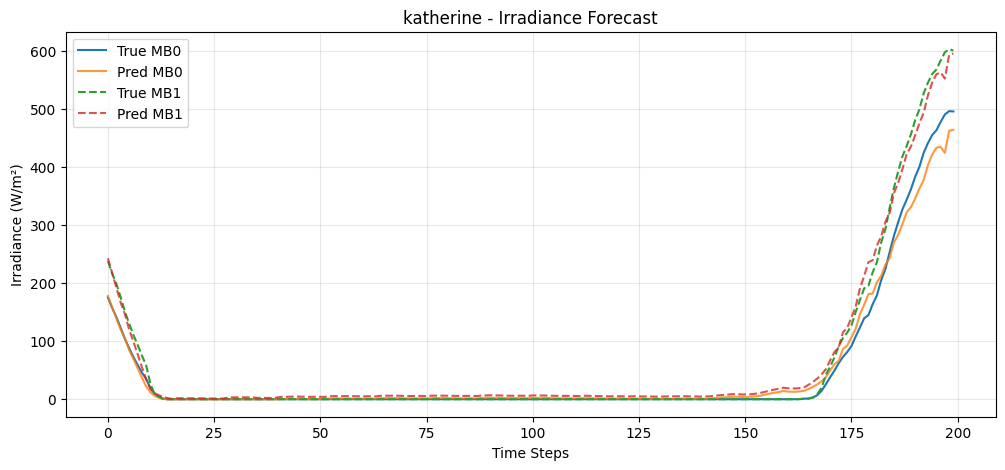


MB0:
  Real (W/m²) - RMSE: 67.03, MAE: 33.77, R²: 0.9637
  Power (kW)  - RMSE: 0.1207, MAE: 0.0608, R²: 0.9637

MB1:
  Real (W/m²) - RMSE: 59.10, MAE: 26.89, R²: 0.9734
  Power (kW)  - RMSE: 0.1064, MAE: 0.0484, R²: 0.9734

  Overall RMSE: 63.19

📍 DARWIN
----------------------------------------


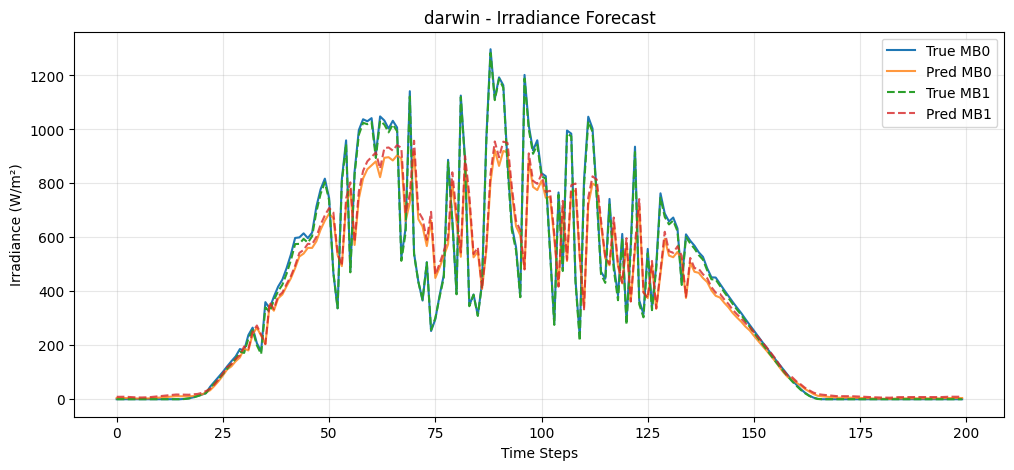


MB0:
  Real (W/m²) - RMSE: 61.96, MAE: 29.33, R²: 0.9610
  Power (kW)  - RMSE: 0.1115, MAE: 0.0528, R²: 0.9610

MB1:
  Real (W/m²) - RMSE: 62.48, MAE: 29.90, R²: 0.9653
  Power (kW)  - RMSE: 0.1125, MAE: 0.0538, R²: 0.9653

  Overall RMSE: 62.22

📍 TENNANT_CREEK
----------------------------------------


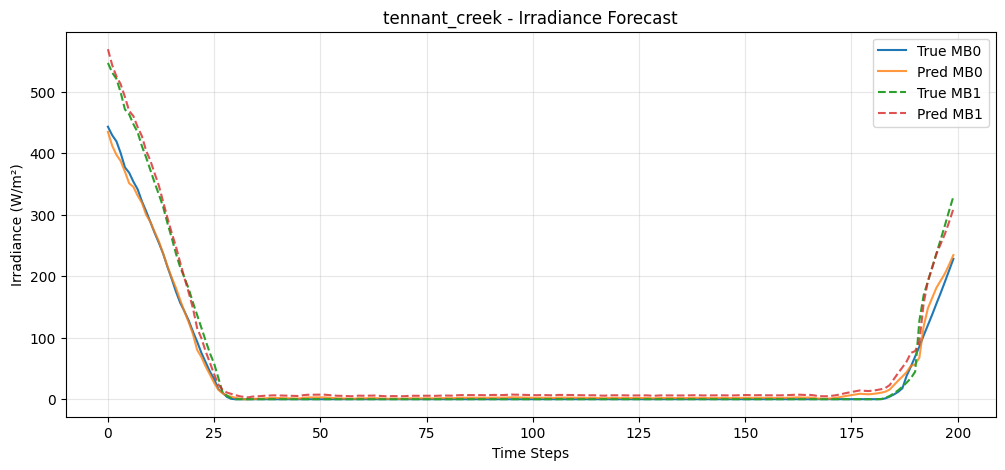


MB0:
  Real (W/m²) - RMSE: 85.54, MAE: 44.26, R²: 0.9414
  Power (kW)  - RMSE: 0.1540, MAE: 0.0797, R²: 0.9414

MB1:
  Real (W/m²) - RMSE: 89.98, MAE: 42.18, R²: 0.9399
  Power (kW)  - RMSE: 0.1620, MAE: 0.0759, R²: 0.9399

  Overall RMSE: 87.79

📍 ALICE_SPRINGS
----------------------------------------


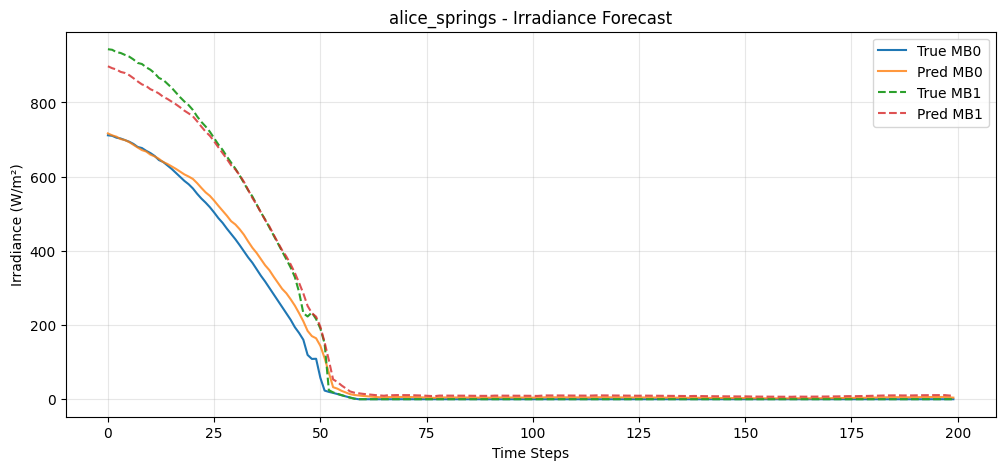


MB0:
  Real (W/m²) - RMSE: 59.87, MAE: 29.78, R²: 0.9730
  Power (kW)  - RMSE: 0.1078, MAE: 0.0536, R²: 0.9730

MB1:
  Real (W/m²) - RMSE: 56.08, MAE: 29.83, R²: 0.9774
  Power (kW)  - RMSE: 0.1010, MAE: 0.0537, R²: 0.9774

  Overall RMSE: 58.01

📉 TEST LOSS EVALUATION
katherine: 0.002147
darwin: 0.001997
tennant_creek: 0.004192
alice_springs: 0.001720

🌍 GLOBAL TEST SET EVALUATION

📈 GLOBAL METRICS:
  Overall - RMSE: 69.11, MAE: 33.48, R²: 0.9619
  Power   - RMSE: 0.1244 kW, MAE: 0.0603 kW, R²: 0.9619

📤 PUSHING TO GOOGLE SHEETS
Prepared 228 cell updates

✅ Server response: 200
📝 Response: {"status":"success","message":"Metrics written to sheet: Sheet90","timestamp":"2026-05-21T13:25:14.997785","cells_updated":228}

✅ EVALUATION COMPLETE


In [34]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import requests
from datetime import datetime
import json
from typing import Dict, Tuple, Optional, Any

# ==========================================================
# CONFIGURATION
# ==========================================================
APPS_SCRIPT_URL = "https://script.google.com/macros/s/AKfycbz6JS-hiL7AFR5EnGfUk6W52HZikalZr6z7jdWiLds1lMEgrTxn4QMjMG17keCqyVLgGQ/exec"
TARGET_SHEET = "Sheet90"

# Power conversion parameters
PV_EFFICIENCY = 0.18  # 18% efficiency
PV_AREA = 10  # m²

# Location mapping for Google Sheets
LOCATION_MAPPING = {
    "katherine": {"col_range": ("B", "C"), "display": "Kathrin"},
    "darwin": {"col_range": ("D", "E"), "display": "Darwin"},
    "tennant_creek": {"col_range": ("F", "G"), "display": "Tennen Creek"},
    "alice_springs": {"col_range": ("H", "I"), "display": "Alice Spring"}
}

TEST_LOSS_ROWS = {"katherine": "40", "darwin": "41", "tennant_creek": "42", "alice_springs": "43"}


# ==========================================================
# UTILITY FUNCTIONS
# ==========================================================
def irradiance_to_power(irradiance: np.ndarray, efficiency: float = PV_EFFICIENCY, area: float = PV_AREA) -> np.ndarray:
    """Convert irradiance (W/m²) to power (kW)"""
    power_watts = efficiency * area * irradiance
    return power_watts / 1000  # kW


def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray, normalize: bool = True) -> Dict[str, float]:
    """
    Compute standard regression metrics.
    
    Args:
        y_true: Ground truth values
        y_pred: Predicted values
        normalize: If True, also compute NMSE and NMAE
    
    Returns:
        Dictionary of metrics
    """
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    metrics = {
        "mse": float(mse),
        "rmse": float(rmse),
        "mae": float(mae),
        "r2": float(r2),
    }
    
    if normalize:
        # Use percentiles to handle outliers
        data_range = np.percentile(y_true, 95) - np.percentile(y_true, 5)
        data_range = max(data_range, 1e-6)
        
        metrics.update({
            "nmse": float(mse / (data_range ** 2)),
            "nmae": float(mae / data_range),
        })
    
    return metrics


# ==========================================================
# CORE EVALUATION FUNCTION (Single Client)
# ==========================================================
def evaluate_client_model(
    model: torch.nn.Module,
    test_loader: torch.utils.data.DataLoader,
    target_scaler: Any,
    device: torch.device,
    compute_power: bool = True
    ) -> Tuple[Optional[Dict], Optional[np.ndarray], Optional[np.ndarray]]:
    
    model.eval()
    
    preds_scaled = []
    true_scaled = []
    
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            
            preds = model(X_batch)
            
            preds_scaled.append(preds.cpu().numpy())
            true_scaled.append(y_batch.cpu().numpy())
    
    if len(preds_scaled) == 0:
        return None, None, None
    
    preds_scaled = np.concatenate(preds_scaled, axis=0)
    true_scaled = np.concatenate(true_scaled, axis=0)
    
    # Inverse transform to real units
    y_pred_real = target_scaler.inverse_transform(preds_scaled)
    y_true_real = target_scaler.inverse_transform(true_scaled)
    y_pred_real = np.clip(y_pred_real, 0, None)  # Physical constraint
    
    target_names = ["MB0", "MB1"]
    results = {"scaled": {}, "real": {}, "normalized": {}, "overall": {}}
    
    if compute_power:
        results["power"] = {}
        power_pred = irradiance_to_power(y_pred_real)
        power_true = irradiance_to_power(y_true_real)
    
    # Per-target metrics
    for i, name in enumerate(target_names):
        # Scaled metrics
        results["scaled"][name] = compute_metrics(
            true_scaled[:, i], preds_scaled[:, i], normalize=False
        )
        
        # Real metrics (W/m²)
        results["real"][name] = compute_metrics(
            y_true_real[:, i], y_pred_real[:, i], normalize=False
        )
        
        # Normalized metrics (using percentiles)
        results["normalized"][name] = compute_metrics(
            y_true_real[:, i], y_pred_real[:, i], normalize=True
        )
        
        # Power metrics (kW)
        if compute_power:
            results["power"][name] = compute_metrics(
                power_true[:, i], power_pred[:, i], normalize=False
            )
    
    # Overall metrics (averaged across targets)
    results["overall"] = {
        "rmse": float(np.sqrt(mean_squared_error(y_true_real, y_pred_real))),
        "mae": float(mean_absolute_error(y_true_real, y_pred_real)),
        "r2": float(r2_score(y_true_real, y_pred_real, multioutput='uniform_average')),
    }
    
    if compute_power:
        # Store power arrays for potential later use
        results["_power_true"] = power_true
        results["_power_pred"] = power_pred
    
    return results, y_true_real, y_pred_real


# ==========================================================
# GLOBAL EVALUATION FUNCTION (Across All Clients)
# ==========================================================

def evaluate_global_model(
    model: torch.nn.Module,
    client_test_loaders: Dict[str, torch.utils.data.DataLoader],
    target_scaler_dict: Dict[str, Any],
    device: torch.device
) -> Tuple[Optional[Dict], Optional[Dict]]:
    """
    Evaluate model across all clients and compute global metrics.
    
    Returns:
        global_metrics: Aggregated metrics across all clients
        per_client_metrics: Individual metrics per client
    """
    model.eval()
    
    all_pred_real = []
    all_true_real = []
    all_power_pred = []
    all_power_true = []
    per_client_metrics = {}
    
    for cid, test_loader in client_test_loaders.items():
        results, y_true, y_pred = evaluate_client_model(
            model, test_loader, target_scaler_dict[cid], device, compute_power=True
        )
        
        if results is None:
            print(f"⚠️ Skipping {cid} (no data)")
            continue
        
        # Store per-client metrics
        per_client_metrics[cid] = {
            "rmse": results["real"]["MB0"]["rmse"],  # Can be averaged if needed
            "mae": results["real"]["MB0"]["mae"],
            "r2": results["real"]["MB0"]["r2"],
            "power": results["power"]["MB0"]
        }
        
        # Collect for global aggregation
        all_true_real.append(y_true)
        all_pred_real.append(y_pred)
        all_power_true.append(results["_power_true"])
        all_power_pred.append(results["_power_pred"])
    
    if len(all_true_real) == 0:
        return None, None
    
    # Concatenate all data
    y_true = np.concatenate(all_true_real, axis=0)
    y_pred = np.concatenate(all_pred_real, axis=0)
    power_true = np.concatenate(all_power_true, axis=0)
    power_pred = np.concatenate(all_power_pred, axis=0)
    
    # Compute global metrics
    target_names = ["MB0", "MB1"]
    global_metrics = {
        "overall": compute_metrics(y_true, y_pred, normalize=False),
        "per_target": {},
        "power": compute_metrics(power_true, power_pred, normalize=True)
    }
    
    for i, name in enumerate(target_names):
        global_metrics["per_target"][name] = compute_metrics(
            y_true[:, i], y_pred[:, i], normalize=True
        )
    
    return global_metrics, per_client_metrics


# ==========================================================
# TEST LOSS EVALUATION
# ==========================================================
def evaluate_test_loss(
    model: torch.nn.Module,
    loader: torch.utils.data.DataLoader,
    loss_fn: torch.nn.Module,
    device: torch.device
) -> float:
    """Compute average loss on test loader"""
    model.eval()
    total_loss = 0.0
    total_samples = 0
    
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            
            preds = model(X_batch)
            loss = loss_fn(preds, y_batch)
            
            batch_sz = X_batch.size(0)
            total_loss += loss.item() * batch_sz
            total_samples += batch_sz
    
    return float('nan') if total_samples == 0 else total_loss / total_samples


# ==========================================================
# PLOTTING FUNCTION
# ==========================================================
def plot_predictions(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    location: str,
    n_samples: int = 200,
    save_path: Optional[str] = None
) -> None:
    """Plot actual vs predicted irradiance"""
    plt.figure(figsize=(12, 5))
    plt.plot(y_true[:n_samples, 0], label="True MB0", linewidth=1.5)
    plt.plot(y_pred[:n_samples, 0], label="Pred MB0", linewidth=1.5, alpha=0.8)
    plt.plot(y_true[:n_samples, 1], label="True MB1", linestyle='--', linewidth=1.5)
    plt.plot(y_pred[:n_samples, 1], label="Pred MB1", linestyle='--', linewidth=1.5, alpha=0.8)
    plt.legend()
    plt.xlabel("Time Steps")
    plt.ylabel("Irradiance (W/m²)")
    plt.title(f"{location} - Irradiance Forecast")
    plt.grid(True, alpha=0.3)
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()


# ==========================================================
# GOOGLE SHEETS INTEGRATION
# ==========================================================
def prepare_sheet_cells(
    per_client_results: Dict[str, Dict],
    global_results: Optional[Dict],
    test_losses: Dict[str, float],
    per_client_global_metrics: Optional[Dict]
) -> Dict[str, Any]:
    """Prepare cell values for Google Sheets"""
    cell_values = {}
    
    # Helper to update cells
    def update_cells(prefix: str, row_start: int, value, col_range: Tuple[str, str] = None):
        for loc, mapping in LOCATION_MAPPING.items():
            if loc not in per_client_results:
                continue
            
            col1, col2 = mapping["col_range"]
            metrics = per_client_results[loc]
            
            if col_range:
                col1, col2 = col_range
            
            for col, target in [(col1, "MB0"), (col2, "MB1")]:
                if isinstance(value, str):
                    cell_values[f"{col}{row_start}"] = value
                elif callable(value):
                    cell_values[f"{col}{row_start}"] = value(metrics, target)
                else:
                    cell_values[f"{col}{row_start}"] = value
    
    # 1. SCALED metrics (B5:I8)
    for row, metric in [(5, "mse"), (6, "rmse"), (7, "mae"), (8, "r2")]:
        for loc, mapping in LOCATION_MAPPING.items():
            if loc in per_client_results:
                col1, col2 = mapping["col_range"]
                metrics = per_client_results[loc]
                cell_values[f"{col1}{row}"] = metrics["scaled"]["MB0"][metric]
                cell_values[f"{col2}{row}"] = metrics["scaled"]["MB1"][metric]
    
    # 2. REAL metrics (B10:I12)
    for row, metric in [(10, "rmse"), (11, "mae"), (12, "r2")]:
        for loc, mapping in LOCATION_MAPPING.items():
            if loc in per_client_results:
                col1, col2 = mapping["col_range"]
                metrics = per_client_results[loc]
                cell_values[f"{col1}{row}"] = metrics["real"]["MB0"][metric]
                cell_values[f"{col2}{row}"] = metrics["real"]["MB1"][metric]
    
    # 3. NORMALIZED metrics (B14:I15)
    for row, metric in [(14, "nmse"), (15, "nmae")]:
        for loc, mapping in LOCATION_MAPPING.items():
            if loc in per_client_results:
                col1, col2 = mapping["col_range"]
                metrics = per_client_results[loc]
                cell_values[f"{col1}{row}"] = metrics["normalized"]["MB0"][metric]
                cell_values[f"{col2}{row}"] = metrics["normalized"]["MB1"][metric]
    
    # 4. OVERALL metrics (B17:I19)
    for row, metric in [(17, "rmse"), (18, "mae"), (19, "r2")]:
        for loc, mapping in LOCATION_MAPPING.items():
            if loc in per_client_results:
                col1, _ = mapping["col_range"]
                cell_values[f"{col1}{row}"] = per_client_results[loc]["overall"][metric]
    
    # 5. POWER metrics (B32:I34)
    if "power" in next(iter(per_client_results.values())) if per_client_results else False:
        for row, metric in [(32, "rmse"), (33, "mae"), (34, "r2")]:
            for loc, mapping in LOCATION_MAPPING.items():
                if loc in per_client_results:
                    col1, col2 = mapping["col_range"]
                    metrics = per_client_results[loc]
                    cell_values[f"{col1}{row}"] = metrics["power"]["MB0"][metric]
                    cell_values[f"{col2}{row}"] = metrics["power"]["MB1"][metric]
    
    # 6. GLOBAL PER-TARGET metrics (B21:I25)
    if global_results:
        metrics_order = [(21, "rmse"), (22, "mae"), (23, "r2"), (24, "nmse"), (25, "nmae")]
        for row, metric in metrics_order:
            for loc, mapping in LOCATION_MAPPING.items():
                col1, col2 = mapping["col_range"]
                cell_values[f"{col1}{row}"] = global_results["per_target"]["MB0"][metric]
                cell_values[f"{col2}{row}"] = global_results["per_target"]["MB1"][metric]
    
    # 7. GLOBAL OVERALL metrics (B27:I29)
    if global_results:
        for row, metric in [(27, "rmse"), (28, "mae"), (29, "r2")]:
            for col in ["B", "C", "D", "E", "F", "G", "H", "I"]:
                cell_values[f"{col}{row}"] = global_results["overall"][metric]
    
    # 8. PER-CLIENT PERFORMANCE (B36:I38)
    if per_client_global_metrics:
        for row, metric in [(36, "rmse"), (37, "mae"), (38, "r2")]:
            for loc, mapping in LOCATION_MAPPING.items():
                if loc in per_client_global_metrics:
                    col1, col2 = mapping["col_range"]
                    value = per_client_global_metrics[loc][metric]
                    cell_values[f"{col1}{row}"] = value
                    cell_values[f"{col2}{row}"] = value
    
    # 9. TEST LOSS metrics (B40:I43)
    for loc, row in TEST_LOSS_ROWS.items():
        if loc in test_losses:
            for col in ["B", "C", "D", "E", "F", "G", "H", "I"]:
                cell_values[f"{col}{row}"] = test_losses[loc]
    
    return cell_values


def push_to_google_sheets(cell_values: Dict[str, Any]) -> bool:
    """Push metrics to Google Sheets"""
    if not cell_values:
        print("❌ No cell values to push.")
        return False
    
    def convert_to_serializable(obj):
        if isinstance(obj, dict):
            return {k: convert_to_serializable(v) for k, v in obj.items()}
        elif isinstance(obj, list):
            return [convert_to_serializable(item) for item in obj]
        elif isinstance(obj, (np.float32, np.float64)):
            return float(obj)
        elif isinstance(obj, (np.int32, np.int64)):
            return int(obj)
        elif isinstance(obj, np.ndarray):
            return obj.tolist()
        return obj
    
    payload = {
        "sheet": TARGET_SHEET,
        "cells": cell_values,
        "timestamp": datetime.now().isoformat()
    }
    
    try:
        response = requests.post(
            APPS_SCRIPT_URL,
            data=json.dumps(payload, default=convert_to_serializable),
            headers={"Content-Type": "application/json"},
            timeout=120
        )
        print(f"\n✅ Server response: {response.status_code}")
        print(f"📝 Response: {response.text}")
        return True
    except Exception as e:
        print(f"\n❌ Error: {e}")
        import traceback
        traceback.print_exc()
        return False


# ==========================================================
# MAIN EXECUTION FUNCTION
# ==========================================================
def run_evaluation(
    global_model: torch.nn.Module,
    pytorch_client_data: Dict[str, Dict],
    scaler_store: Dict[str, Dict],
    device: torch.device,
    plot_predictions_flag: bool = True,
    push_to_sheets: bool = True
) -> Tuple[Dict, Dict, Dict]:
    """
    Main evaluation function that orchestrates all evaluations.
    
    Returns:
        per_client_results: Metrics per client
        global_results: Aggregated metrics
        test_losses: Test loss per client
    """
    print("\n" + "=" * 60)
    print("SOLAR IRRADIANCE MODEL EVALUATION")
    print("=" * 60)
    
    global_model.eval()
    loss_fn = torch.nn.MSELoss()
    
    # ==========================================================
    # 1. PER-CLIENT EVALUATION
    # ==========================================================
    print("\n📊 PER-CLIENT TEST SET EVALUATION")
    print("=" * 60)
    
    per_client_results = {}
    
    for loc in pytorch_client_data.keys():
        print(f"\n📍 {loc.upper()}")
        print("-" * 40)
        
        results, y_true, y_pred = evaluate_client_model(
            model=global_model,
            test_loader=pytorch_client_data[loc]["test_dataloader"],
            target_scaler=scaler_store[loc]["target_scaler"],
            device=device,
            compute_power=True
        )
        
        if results is None:
            print("⚠️ Empty test loader.")
            continue
        
        per_client_results[loc] = results
        
        # Plot predictions
        if plot_predictions_flag:
            plot_predictions(y_true, y_pred, loc, n_samples=200)
        
        # Print metrics summary
        for target in ["MB0", "MB1"]:
            print(f"\n{target}:")
            print(f"  Real (W/m²) - RMSE: {results['real'][target]['rmse']:.2f}, MAE: {results['real'][target]['mae']:.2f}, R²: {results['real'][target]['r2']:.4f}")
            if "power" in results:
                print(f"  Power (kW)  - RMSE: {results['power'][target]['rmse']:.4f}, MAE: {results['power'][target]['mae']:.4f}, R²: {results['power'][target]['r2']:.4f}")
        
        print(f"\n  Overall RMSE: {results['overall']['rmse']:.2f}")
    
    # ==========================================================
    # 2. TEST LOSS EVALUATION
    # ==========================================================
    print("\n" + "=" * 60)
    print("📉 TEST LOSS EVALUATION")
    print("=" * 60)
    
    test_losses = {}
    for loc, client_data in pytorch_client_data.items():
        loss = evaluate_test_loss(global_model, client_data["test_dataloader"], loss_fn, device)
        test_losses[loc] = loss
        print(f"{loc}: {loss:.6f}")
    
    # ==========================================================
    # 3. GLOBAL EVALUATION
    # ==========================================================
    print("\n" + "=" * 60)
    print("🌍 GLOBAL TEST SET EVALUATION")
    print("=" * 60)
    
    global_results, per_client_global_metrics = evaluate_global_model(
        model=global_model,
        client_test_loaders={cid: data["test_dataloader"] for cid, data in pytorch_client_data.items()},
        target_scaler_dict={cid: scaler_store[cid]["target_scaler"] for cid in pytorch_client_data.keys()},
        device=device
    )
    
    if global_results:
        print("\n📈 GLOBAL METRICS:")
        print(f"  Overall - RMSE: {global_results['overall']['rmse']:.2f}, MAE: {global_results['overall']['mae']:.2f}, R²: {global_results['overall']['r2']:.4f}")
        print(f"  Power   - RMSE: {global_results['power']['rmse']:.4f} kW, MAE: {global_results['power']['mae']:.4f} kW, R²: {global_results['power']['r2']:.4f}")
    
    # ==========================================================
    # 4. PUSH TO GOOGLE SHEETS (OPTIONAL)
    # ==========================================================
    if push_to_sheets:
        print("\n" + "=" * 60)
        print("📤 PUSHING TO GOOGLE SHEETS")
        print("=" * 60)
        
        cell_values = prepare_sheet_cells(
            per_client_results, global_results, test_losses, per_client_global_metrics
        )
        print(f"Prepared {len(cell_values)} cell updates")
        push_to_google_sheets(cell_values)
    
    print("\n" + "=" * 60)
    print("✅ EVALUATION COMPLETE")
    print("=" * 60)
    
    return per_client_results, global_results, test_losses


# ==========================================================
# USAGE EXAMPLE
# ==========================================================
if __name__ == "__main__":

    # global_model.load_state_dict(torch.load('/kaggle/input/models/alhossainabid1/solar-panal-global-avg-model/pytorch/default/4/hidden_size_2.pth', map_location=device))
    global_model.eval()

    per_client_results, global_results, test_losses = run_evaluation(
        global_model=global_model,
        pytorch_client_data=pytorch_client_data,
        scaler_store=scaler_store,
        device=device,
        plot_predictions_flag=True,
        push_to_sheets=True
    )

# MC Drop

## _Load the model_

In [35]:
# global_model.load_state_dict(torch.load('/kaggle/input/models/alhossainabid1/solar-panal-global-avg-model/pytorch/default/4/hidden_size_2.pth', map_location=device))
# global_model.eval()

In [36]:
import numpy as np
import torch

def mc_dropout_test(model, test_loader, device, T=50):
    
    model.train()  # IMPORTANT: enables dropout

    all_means = []
    all_stds = []
    all_true = []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.cpu().numpy()

            mc_preds = []

            # -------------------------
            # MC sampling loop
            # -------------------------
            for _ in range(T):
                preds = model(X_batch)
                mc_preds.append(preds.cpu().numpy())

            mc_preds = np.array(mc_preds)  # (T, batch, 2)

            mean_preds = mc_preds.mean(axis=0)   # (batch, 2)
            std_preds  = mc_preds.std(axis=0)    # (batch, 2)

            all_means.append(mean_preds)
            all_stds.append(std_preds)
            all_true.append(y_batch)

    mean_pred = np.concatenate(all_means, axis=0)
    std_pred  = np.concatenate(all_stds, axis=0)
    true_vals = np.concatenate(all_true, axis=0)

    return mean_pred, std_pred, true_vals

In [37]:
mean_pred, std_pred, y_true = mc_dropout_test(
    model=global_model,
    test_loader=pytorch_client_data["katherine"]["test_dataloader"],
    device=device,
    T=50
)

In [38]:
print(f"mean_pred: {mean_pred}")
print(f"std_pred: {std_pred}")


mean_pred: [[0.2380549  0.35795322]
 [0.20222755 0.3050164 ]
 [0.16387731 0.25523317]
 ...
 [0.60341746 0.6657135 ]
 [0.15553786 0.18368688]
 [0.3305994  0.38461468]]
std_pred: [[0.02352368 0.03702736]
 [0.01843368 0.02847994]
 [0.01987341 0.03259119]
 ...
 [0.0493209  0.04927266]
 [0.02179416 0.02656934]
 [0.02824884 0.03422702]]


## Risk Detector

In [39]:
risk_score = np.mean(std_pred / (mean_pred + 1e-6))
if risk_score < 0.05:
    print("Low Risk ☀️")
elif risk_score < 0.15:
    print("Medium Risk 🌤️")
else:
    print("High Risk 🌧️")

Medium Risk 🌤️


## Visulalize

In [40]:
import numpy as np
import matplotlib.pyplot as plt

def plot_solar_risk(mean_pred, std_pred, title="Solar Risk Visualization", idx=300):

    # --------------------------
    # Risk computation
    # --------------------------
    
    risk = std_pred / (mean_pred + 1e-6)
    risk_score = np.mean(risk)

    x = np.arange(len(mean_pred[:idx]))

    # --------------------------
    # Plot setup
    # --------------------------
    plt.figure(figsize=(14, 6))

    # 🌤️ Mean irradiance
    plt.plot(x, mean_pred[:idx, 0], label="MB0 Mean Irradiance", color="orange")
    plt.plot(x, mean_pred[:idx, 1], label="MB1 Mean Irradiance", color="gold", linestyle="--")

    # 🌫️ Uncertainty band (MB0)
    plt.fill_between(
        x,
        mean_pred[:idx, 0] - std_pred[:idx, 0],
        mean_pred[:idx, 0] + std_pred[:idx, 0],
        alpha=0.2,
        color="green",
        label="MB0 Uncertainty"
    )

    # 🌫️ Uncertainty band (MB1)
    plt.fill_between(
        x,
        mean_pred[:idx, 1] - std_pred[:idx, 1],
        mean_pred[:idx, 1] + std_pred[:idx, 1],
        alpha=0.2,
        color="blue",
        label="MB1 Uncertainty"
    )

    # ⚠️ Risk curve (scaled for visibility)
    risk_scaled = (risk[:idx, 0] + risk[:idx, 1]) / 2
    plt.plot(x, risk_scaled, label="Risk Score", color="red", linewidth=2)

    # --------------------------
    # Styling
    # --------------------------
    plt.title(f"{title} | Avg Risk Score: {risk_score:.4f}")
    plt.xlabel("Time Step")
    plt.ylabel("Normalized Value")
    plt.legend()
    plt.grid(True)
    plt.savefig(f"{title}.png", dpi =300)
    plt.show()

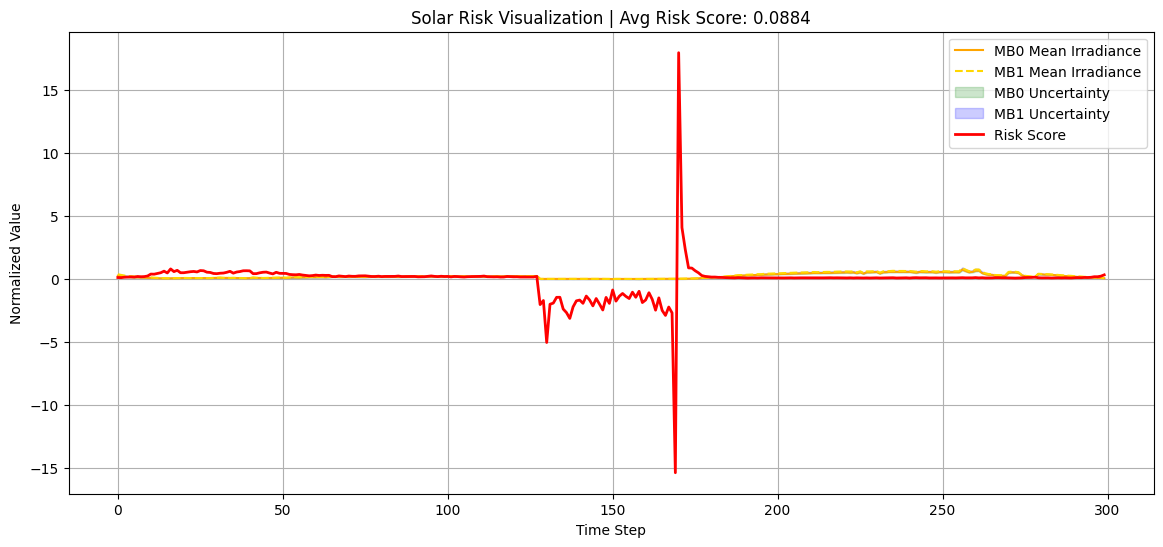

In [41]:
plot_solar_risk(mean_pred, std_pred, idx=300)

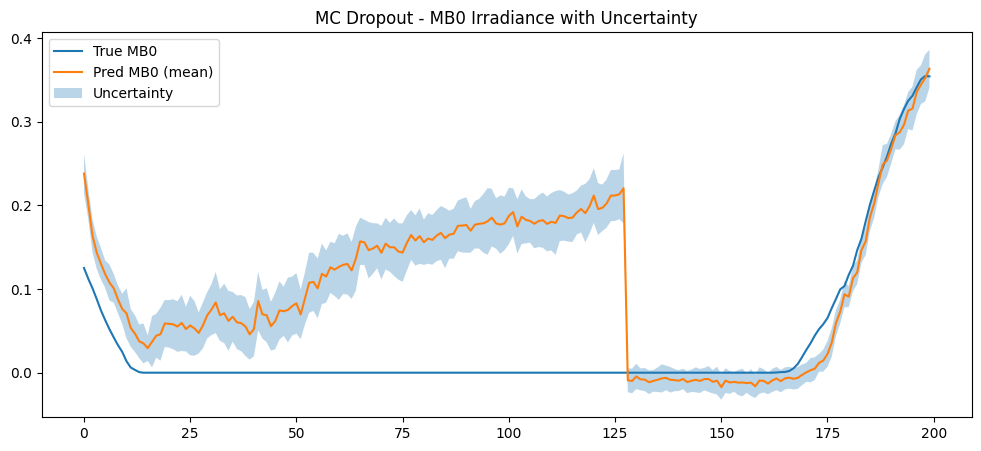

In [42]:
import matplotlib.pyplot as plt

idx = 200  # first samples

plt.figure(figsize=(12,5))

# True
plt.plot(y_true[:idx, 0], label="True MB0")

# Mean prediction
plt.plot(mean_pred[:idx, 0], label="Pred MB0 (mean)")

# Uncertainty band
plt.fill_between(
    np.arange(idx),
    mean_pred[:idx, 0] - std_pred[:idx, 0],
    mean_pred[:idx, 0] + std_pred[:idx, 0],
    alpha=0.3,
    label="Uncertainty"
)

plt.legend()
plt.title("MC Dropout - MB0 Irradiance with Uncertainty")
plt.show()

# Prediction + Uncertainty Band

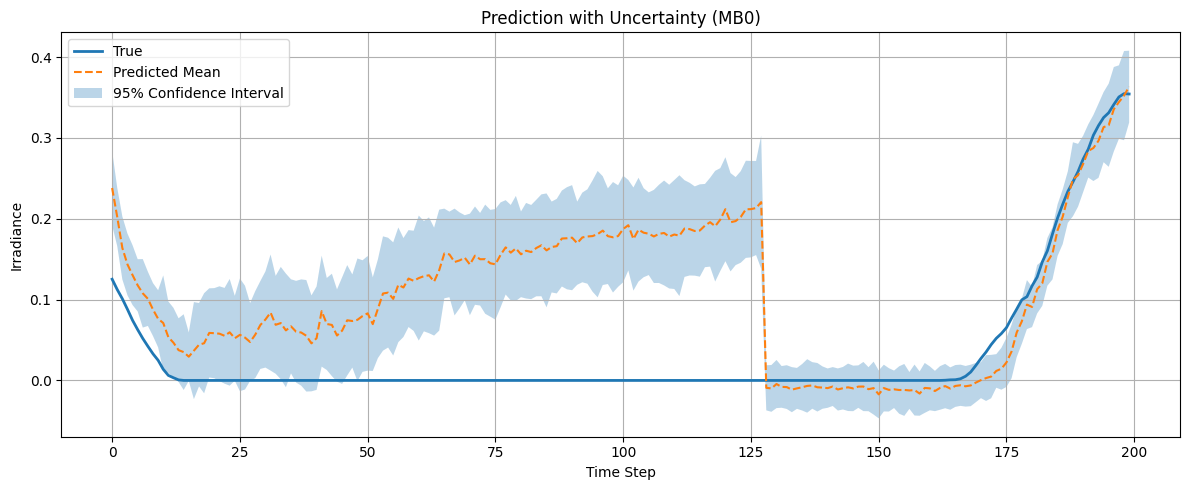

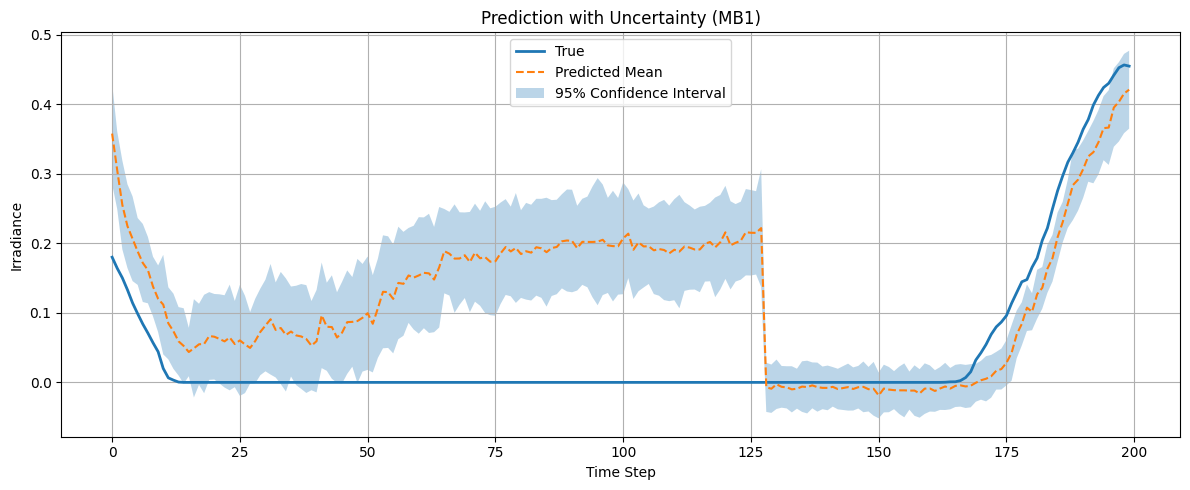

In [43]:
import matplotlib.pyplot as plt
import numpy as np

def plot_prediction_with_uncertainty(mean_pred, std_pred, y_true, target_idx=0, n_points=200):
    """
    target_idx: 0 -> MB0, 1 -> MB1
    n_points: number of time steps to visualize
    """

    mean = mean_pred[:n_points, target_idx]
    std = std_pred[:n_points, target_idx]
    true = y_true[:n_points, target_idx]

    lower = mean - 1.96 * std
    upper = mean + 1.96 * std

    x = np.arange(n_points)

    plt.figure(figsize=(12, 5))
    plt.plot(x, true, label="True", linewidth=2)
    plt.plot(x, mean, label="Predicted Mean", linestyle="--")
    plt.fill_between(x, lower, upper, alpha=0.3, label="95% Confidence Interval")

    plt.xlabel("Time Step")
    plt.ylabel("Irradiance")
    plt.title(f"Prediction with Uncertainty (MB{target_idx})")
    plt.legend()
    plt.grid()

    plt.tight_layout()
    plt.savefig(f"Prediction with Uncertainty (MB{target_idx}).png", dpi=300)
    plt.show()

plot_prediction_with_uncertainty(mean_pred, std_pred, y_true, target_idx=0)
plot_prediction_with_uncertainty(mean_pred, std_pred, y_true, target_idx=1)

## Get MC DROP SAMPLE

In [44]:
def get_mc_samples(model, loader, device, T=50):

    model.train().to(device)  # dropout ON

    all_samples = []
    all_true = []

    with torch.no_grad():
        for X, y in loader:
            X = X.to(device)

            preds_T = []

            for _ in range(T):
                preds_T.append(model(X).cpu().numpy())

            preds_T = np.stack(preds_T, axis=0)  # (T, B, 2)

            all_samples.append(preds_T)
            all_true.append(y.numpy())

    mc_preds = np.concatenate(all_samples, axis=1)  # (T, N, 2)
    y_true = np.concatenate(all_true, axis=0)

    return mc_preds, y_true

mc_preds, y_true = get_mc_samples(
    global_model,
    pytorch_client_data["katherine"]["test_dataloader"],
    device,
    T=200
)

# Reliability Diagram (Calibration Curve)

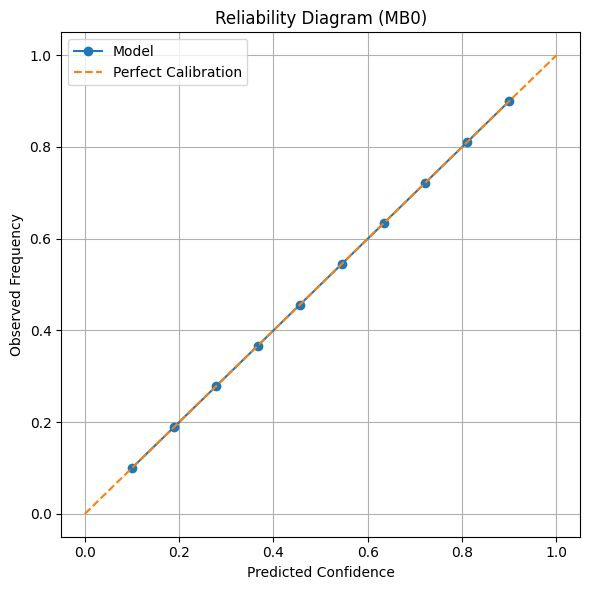

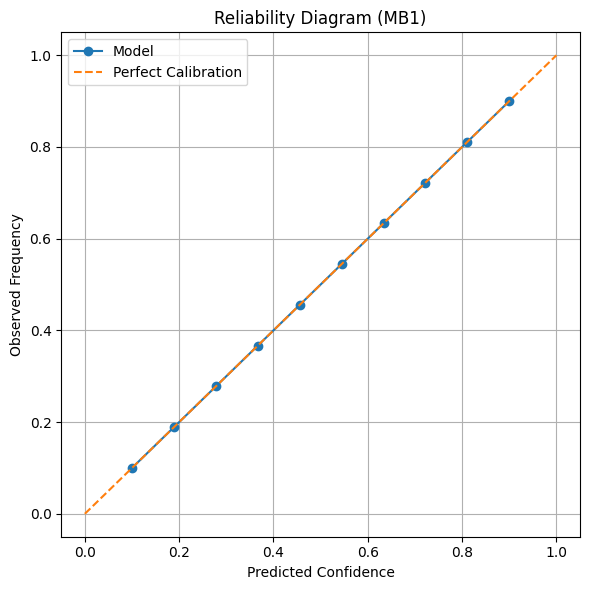

In [45]:
def plot_reliability_diagram(mc_preds, y_true, target_idx=0, num_bins=10):
    """
    mc_preds: (T, N, 2)
    """

    samples = mc_preds[:, :, target_idx]  # (T, N)
    true = y_true[:, target_idx]

    mean = samples.mean(axis=0)
    std = samples.std(axis=0)

    z_scores = np.abs(true - mean) / (std + 1e-6)

    confidences = np.linspace(0.1, 0.9, num_bins)
    observed = []

    for c in confidences:
        threshold = np.quantile(z_scores, c)
        observed.append(np.mean(z_scores <= threshold))

    plt.figure(figsize=(6, 6))
    plt.plot(confidences, observed, marker='o', label="Model")
    plt.plot([0, 1], [0, 1], linestyle='--', label="Perfect Calibration")

    plt.xlabel("Predicted Confidence")
    plt.ylabel("Observed Frequency")
    plt.title(f"Reliability Diagram (MB{target_idx})")
    plt.legend()
    plt.grid()
    plt.savefig(f"Reliability Diagram (MB{target_idx}).png", dpi=300)
    plt.tight_layout()
    plt.show()

plot_reliability_diagram(mc_preds, y_true, target_idx=0)
plot_reliability_diagram(mc_preds, y_true, target_idx=1)

# Interval Width (Sharpness)

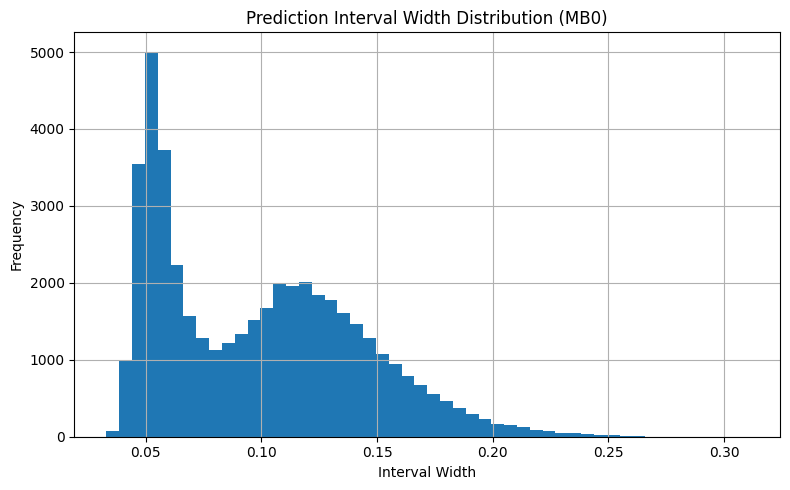

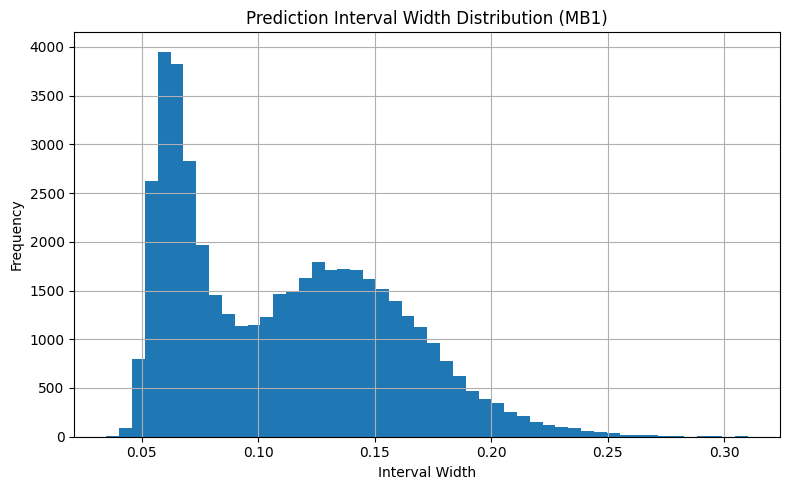

In [46]:
def plot_interval_width(std_pred, target_idx=0):
    widths = 2 * 1.96 * std_pred[:, target_idx]

    plt.figure(figsize=(8, 5))
    plt.hist(widths, bins=50)

    plt.xlabel("Interval Width")
    plt.ylabel("Frequency")
    plt.title(f"Prediction Interval Width Distribution (MB{target_idx})")

    plt.grid()
    plt.tight_layout()
    plt.savefig(f"Prediction Interval Width Distribution (MB{target_idx}).png", dpi=300)
    plt.show()

plot_interval_width(std_pred, target_idx=0)
plot_interval_width(std_pred, target_idx=1)

# Uncertainty vs Prediction

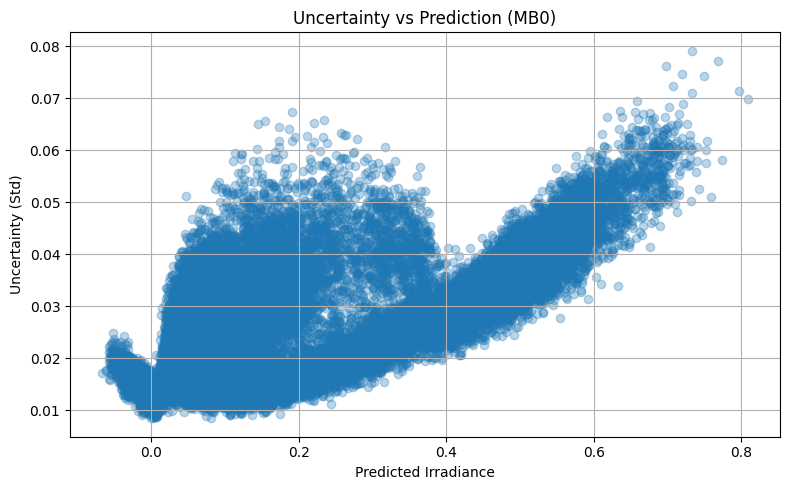

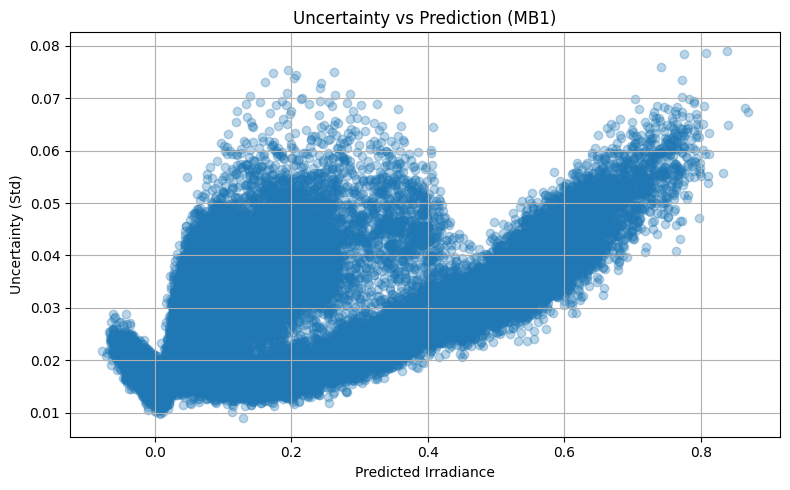

In [47]:
def plot_uncertainty_vs_prediction(mean_pred, std_pred, target_idx=0):
    mean = mean_pred[:, target_idx]
    std = std_pred[:, target_idx]

    plt.figure(figsize=(8, 5))
    plt.scatter(mean, std, alpha=0.3)

    plt.xlabel("Predicted Irradiance")
    plt.ylabel("Uncertainty (Std)")
    plt.title(f"Uncertainty vs Prediction (MB{target_idx})")

    plt.grid()
    plt.tight_layout()
    plt.savefig(f"Uncertainty vs Prediction (MB{target_idx}).png", dpi=300)
    plt.show()

plot_uncertainty_vs_prediction(mean_pred, std_pred, target_idx=0)
plot_uncertainty_vs_prediction(mean_pred, std_pred, target_idx=1)

# Pinball Loss

## Get quantiles from MC samples

In [48]:
def get_quantiles(mc_preds, quantiles=[0.1, 0.5, 0.9]):
    """
    mc_preds: (T, N, 2)
    returns: dict of quantiles
    """
    q_dict = {}
    for q in quantiles:
        q_dict[q] = np.quantile(mc_preds, q, axis=0)  # (N, 2)
    return q_dict

## Pinball Loss function

In [49]:
def pinball_loss(y_true, y_pred, q):
    """
    y_true: (N,)
    y_pred: (N,)
    """
    diff = y_true - y_pred
    return np.mean(np.maximum(q * diff, (q - 1) * diff))

## Compute for MB0 & MB1

In [50]:
def evaluate_pinball(mc_preds, y_true, quantiles=[0.1, 0.5, 0.9]):
    q_preds = get_quantiles(mc_preds, quantiles)

    results = {}

    for q in quantiles:
        losses = []
        for d in range(2):  # MB0, MB1
            loss = pinball_loss(
                y_true[:, d],
                q_preds[q][:, d],
                q
            )
            losses.append(loss)

        results[q] = losses

    return results

In [51]:
pinball_results = evaluate_pinball(mc_preds, y_true)

for q, vals in pinball_results.items():
    print(f"Quantile {q}: MB0={vals[0]:.4f}, MB1={vals[1]:.4f}")

Quantile 0.1: MB0=0.0332, MB1=0.0391
Quantile 0.5: MB0=0.0470, MB1=0.0514
Quantile 0.9: MB0=0.0388, MB1=0.0388


# CRPS

In [52]:
import numpy as np


def crps_mc_multivariate(mc_preds, y_true):
    """
    mc_preds: (T, N, 2)
    y_true:   (N, 2)
    """

    T, N, D = mc_preds.shape
    crps_results = {}

    for d in range(D):  # MB0, MB1

        samples = mc_preds[:, :, d]  # (T, N)
        truth = y_true[:, d]         # (N,)

        crps_total = 0.0

        for i in range(N):
            s = samples[:, i]  # (T,)
            y = truth[i]

            # 1st term: accuracy term
            term1 = np.mean(np.abs(s - y))

            # 2nd term: sharpness term
            term2 = 0.5 * np.mean(np.abs(s[:, None] - s[None, :]))

            crps_total += term1 - term2

        crps_results[f"MB{d}"] = crps_total / N

    return crps_results



crps_scores = crps_mc_multivariate(mc_preds, y_true)


print("CRPS Results:")
print(f"MB0: {crps_scores['MB0']:.6f}")
print(f"MB1: {crps_scores['MB1']:.6f}")


CRPS Results:
MB0: 0.081980
MB1: 0.089266


# PIPC

In [53]:
import numpy as np
import torch

def mc_dropout_full(model, test_loader, device, T=50):
    
    model.train()  # enable dropout

    all_samples = []
    all_true = []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)

            mc_preds = []

            for _ in range(T):
                preds = model(X_batch)
                mc_preds.append(preds.cpu().numpy())

            mc_preds = np.stack(mc_preds, axis=0)  # (T, batch, 2)

            all_samples.append(mc_preds)
            all_true.append(y_batch.numpy())

    # 🔥 IMPORTANT PART
    mc_preds = np.concatenate(all_samples, axis=1)  # (T, N, 2)
    y_true = np.concatenate(all_true, axis=0)

    # still compute mean/std if needed
    mean_pred = mc_preds.mean(axis=0)
    std_pred  = mc_preds.std(axis=0)

    return mc_preds, mean_pred, std_pred, y_true


mc_preds, mean_pred, std_pred, y_true = mc_dropout_full(
    global_model,
    pytorch_client_data["katherine"]["test_dataloader"],
    device,
    T=100
)

import numpy as np

def compute_picp(mc_preds, y_true, lower_q=0.05, upper_q=0.95):
    """
    mc_preds: (T, N, 2)
    y_true:   (N, 2)

    returns:
        picp: list [MB0, MB1]
    """

    # Compute quantile-based interval
    lower = np.quantile(mc_preds, lower_q, axis=0)  # (N, 2)
    upper = np.quantile(mc_preds, upper_q, axis=0)  # (N, 2)

    picp = []

    for d in range(2):  # MB0, MB1
        inside = (y_true[:, d] >= lower[:, d]) & (y_true[:, d] <= upper[:, d])
        coverage = np.mean(inside)
        picp.append(coverage)

    return picp

picp = compute_picp(mc_preds, y_true)

print(f"PICP (MB0): {picp[0]:.4f}")
print(f"PICP (MB1): {picp[1]:.4f}")



PICP (MB0): 0.3238
PICP (MB1): 0.3139


# PINAW

In [54]:
def compute_pinaw(mc_preds, lower_q=0.05, upper_q=0.95):
    lower = np.quantile(mc_preds, lower_q, axis=0)
    upper = np.quantile(mc_preds, upper_q, axis=0)

    widths = upper - lower  # (N, 2)

    return np.mean(widths, axis=0)

pinaw = compute_pinaw(mc_preds)

print(f"PINAW (MB0): {pinaw[0]:.4f}")
print(f"PINAW (MB1): {pinaw[1]:.4f}")

PINAW (MB0): 0.0820
PINAW (MB1): 0.0920
